### 1. Conectar con Google Drive e Importar Librerías
Ejecuta la siguiente celda para dar acceso a Colab a tus archivos de Drive e importar `pandas` y `numpy`.

In [225]:
import os
import numpy as np
import pandas as pd
from google.colab import drive

# Montar Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 2. Configurar la Ruta y Listar Archivos
Por defecto, al montar Google Drive, tu unidad principal se encuentra en `/content/drive/My Drive/`.

IMPORTANTE => Hacer un acceso directo de la carpeta Datos a tu unidad para que el programa pueda leer los archivos.


In [226]:
import os
import pandas as pd

def buscar_ruta_carpeta(nombre_carpeta_buscar, ruta_principal = '/content/drive/My Drive/Datos'):
    # Esta función busca de manera insensible a mayúsculas/minúsculas
    nombre_buscar_lower = nombre_carpeta_buscar.lower()

    for raiz, directorios, archivos in os.walk(ruta_principal):
        for directorio in directorios:
            if directorio.lower() == nombre_buscar_lower:
                return os.path.join(raiz, directorio)
    return None

nombre_carpeta = 'datos vacas en establo marzo_junio_2025'
ruta_final = buscar_ruta_carpeta(nombre_carpeta)

if ruta_final:
    print(f"¡Éxito! Carpeta detectada en: {ruta_final}\n")
    archivos = [f for f in os.listdir(ruta_final) if f.endswith('.csv')]
    print(f"Se encontraron {len(archivos)} archivos de datos relevantes:")
    for i, archivo in enumerate(archivos[:10], 1):
        print(f"{i}. {archivo}")
    if len(archivos) > 10:
        print("... y más.")
else:
    print("Aún no se detectó el acceso directo. Por favor verifica que esté en 'Mi Unidad/Datos/datos vacas en establo marzo_junio_2025' y vuelve a ejecutar esta celda.")

¡Éxito! Carpeta detectada en: /content/drive/My Drive/Datos/DATOS vacas en establo marzo_junio_2025

Se encontraron 37 archivos de datos relevantes:
1. 6232.csv
2. 2076.csv
3. 6003.csv
4. 8775.csv
5. reporte_180725.csv
6. 1613.csv
7. 6211.csv
8. 8729.csv
9. 1624.csv
10. inventario_total_180725.csv
... y más.


### 4. Lectura, Consolidación y Ordenamiento de los Datos
El siguiente código leerá todos los archivos de datos encontrados en la carpeta, omitirá la primera fila de datos de cada uno (manteniendo la estructura de cabeceras), combinará toda la información en un solo DataFrame de Pandas y finalmente ordenará los registros por la columna **'hora_inicio'**.

In [227]:
import os
import pandas as pd

lista_df = []
column_names = [
    # Main
    "hora_inicio",
    "accion",
    "duracion",
    "produccion_kg",
    "numero_ordeños",
    "rcs_celulas_ml",
    "patada",
    "incompleto",
    "pezones_no_encontrados",
    
    # Estado AMD
    'estado_amd_ubre',
    'estado_amd_pezon',
    
    # Media Flujos
    "media_flujos_di",
    "media_flujos_dd",
    "media_flujos_ti",
    "media_flujos_td",
    
    # Sangre (ppm)
    "sangre_di",
    "sangre_dd",
    "sangre_ti",
    "sangre_td",
    
    # Conductividad
    "conductividad_di",
    "conductividad_dd",
    "conductividad_ti",
    "conductividad_td",
    
    # Misc
    'eo_po',
    'usuario',
    'destino_leche',
    'razon_de_desviacion',
    
    # Flujo Máximo
    "flujo_maximo_di",
    "flujo_maximo_dd",
    "flujo_maximo_ti",
    "flujo_maximo_td",
    
    # Producción
    "produccion_di",
    "produccion_dd",
    "produccion_ti",
    "produccion_td",
]

print("Iniciando la lectura de archivos...")
for archivo in archivos:
    # Omitir archivos que no empiecen con un número
    if not archivo[0].isdigit():
        continue

    ruta_archivo = os.path.join(ruta_final, archivo)

    try:
        # Leer según el tipo de extensión del archivo
        # skiprows=1 se usa para saltarse la primera línea de datos físicos del archivo.
        df_temp = pd.read_csv(ruta_archivo, skiprows=1, names=column_names)

        # Añadir una columna para saber de qué archivo proviene cada registro
        df_temp['origen_archivo'] = archivo
        df_temp['id_vaca'] = archivo.split(".")[0]
        lista_df.append(df_temp)

    except Exception as e:
        print(f"No se pudo procesar el archivo {archivo}. Error: {e}")

print(f"\nArchivos procesados correctamente: {len(lista_df)}")
if lista_df:
    print(f"Columnas que deberían de tener: {len(lista_df[0].columns)}")
    acum = {'sum': 0, 'max': 0, 'min': 9999}
    for df in (lista_df):
      acum["sum"] += len(df.columns)
      acum["max"] = max(acum["max"], len(df.columns))
      acum["min"] = min(acum["min"], len(df.columns))

    print(f"Promedio de categorías: {acum['sum'] / len(lista_df)}")
    print(f"Máximo de categorías:  {acum['max']}")
    print(f"Mínimo de categorías: {acum['min']}")

Iniciando la lectura de archivos...



Archivos procesados correctamente: 34
Columnas que deberían de tener: 37
Promedio de categorías: 37.0
Máximo de categorías:  37
Mínimo de categorías: 37


In [228]:
# Concatenar todos los dataframes en uno solo
if lista_df:
    df_consolidado = pd.concat(lista_df, ignore_index=True)
    print(f"\n¡Unión completada! Total de registros cargados: {len(df_consolidado)}")

    # Intentar ordenar por 'hora_inicio' si la columna existe
    columna_orden = 'hora_inicio'
    if columna_orden in df_consolidado.columns:
        # Convertimos a tipo datetime para ordenar cronológicamente de forma correcta
        df_consolidado[columna_orden] = pd.to_datetime(df_consolidado[columna_orden], errors='coerce')
        df_consolidado = df_consolidado.sort_values(by=columna_orden).reset_index(drop=True)
        print(f"Datos ordenados correctamente por '{columna_orden}'.")
    else:
        print(f"\nAdvertencia: No se encontró la columna '{columna_orden}' para ordenar. Las columnas disponibles son:")
        print(list(df_consolidado.columns))

    # Mostrar una vista previa del DataFrame final
    display(df_consolidado.head())
else:
    print("No se cargó ningún dato. Verifica que los archivos no estén vacíos o corruptos.")


¡Unión completada! Total de registros cargados: 7283


/tmp/ipykernel_1827/4082967169.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_consolidado[columna_orden] = pd.to_datetime(df_consolidado[columna_orden], errors='coerce')


Datos ordenados correctamente por 'hora_inicio'.


,hora_inicio,accion,duracion,produccion_kg,numero_ordeños,rcs_celulas_ml,patada,incompleto,pezones_no_encontrados,estado_amd_ubre,...,flujo_maximo_di,flujo_maximo_dd,flujo_maximo_ti,flujo_maximo_td,produccion_di,produccion_dd,produccion_ti,produccion_td,origen_archivo,id_vaca
0,2025-01-03 00:06:00,Ordeño,06:54,16.30,1,NaN,NaN,NaN,NaN,0,...,1.50,1.62,1.68,1.74,3.77,3.25,5.03,4.25,1624.csv,1624
1,2025-01-03 00:16:00,Ordeño,08:58,14.48,1,NaN,TI,NaN,NaN,0,...,1.08,1.38,1.20,1.26,3.07,2.75,4.31,4.35,1613.csv,1613
2,2025-01-03 00:49:00,Ordeño,10:28,7.28,1,NaN,DI,"TI,TD",TD,1,...,1.92,2.40,1.98,0.00,2.34,4.23,0.71,0.00,6178.csv,6178
3,2025-01-03 01:06:00,Ordeño,08:29,20.64,1,NaN,NaN,NaN,NaN,0,...,1.68,1.62,1.50,1.86,4.62,3.88,6.17,5.97,6194.csv,6194
4,2025-01-03 01:37:00,Ordeño,07:55,23.08,1,NaN,NaN,NaN,NaN,0,...,1.80,2.22,2.82,2.10,2.58,3.29,8.63,8.58,6238.csv,6238


### 5. Procesamiento de Nuevos Datos Históricos (Clasificación por tipo de archivo)
En esta sección clasificamos los archivos `.xlsx` de la carpeta `Datos vacas historico hasta enero 2026/TEC-UAQ-UNAM` en diferentes DataFrames según su prefijo.

In [229]:
import os
import pandas as pd

# 1. Definir y buscar la nueva carpeta de datos históricos
nombre_carpeta = 'TEC-UAQ-UNAM'
ruta_historico = buscar_ruta_carpeta(nombre_carpeta, ruta_principal='/content/drive/My Drive/Datos/Datos vacas historico hasta enero 2026')

consumo = [
  'alimento',
  'hora_evento',
  'consumo',
  'consumido'
]

produccion = [
    # Main
    "hora_inicio",
    "numero_ordenio",
    "duracion",
    "produccion_kg",
    "rcs_celulas_ml",
    "intervalo_ordenio",
    
    # Producción por ubre
    "produccion_di",
    "produccion_dd",
    "produccion_ti",
    "produccion_td",

    # Estado AMD
    "estado_md_ubre",
    "estado_md_pezon",
    
    # Media Flujo
    "media_flujo_di",
    "media_flujo_dd",
    "media_flujo_ti",
    "media_flujo_td",
    
    # Flujo Máximo
    "flujo_maximo_di",
    "flujo_maximo_dd",
    "flujo_maximo_ti",
    "flujo_maximo_td",

    # Sangre (ppm)
    "sangre_di",
    "sangre_dd",
    "sangre_ti",
    "sangre_td",
    

    # Conductividad
    "conductividad_di",
    "conductividad_dd",
    "conductividad_ti",
    "conductividad_td",

    # Contadores Monitorización Vaca
    "contador_ubre",
    "contador_di",
    "contador_dd",
    "contador_td",
    "contador_ti",

    # Misc
    'destino_leche',
    'razon_desviacion',
    'programa_lavado',
    'ms',
    'usuario',

    # Estado
    'patada',
    'incompleto',
    'pezones_no_encotnrados',
    'mdi',
]

def read_detailed_data():
  if ruta_historico:
      print(f"¡Éxito! Carpeta detectada en: {ruta_historico}\n")

      # Listar todos los archivos Excel (.xlsx)
      todos_archivos = [f for f in os.listdir(ruta_historico) if f.endswith('.xlsx') or f.endswith('.xls')]
      print(f"Se encontraron {len(todos_archivos)} archivos Excel en total.")

      # Inicializar listas para clasificar los DataFrames
      lista_concentrado = []
      lista_produccion_leche = []

      # 2. Iterar y clasificar los archivos
      for archivo in todos_archivos:
          ruta_archivo = os.path.join(ruta_historico, archivo)

          # Extraer el ID o número del animal del nombre del archivo como referencia
          # Ej: 'Concentrado consumido 216.xlsx' -> extrae '216'
          id_vaca = "".join(filter(str.isdigit, archivo))

          try:
              if archivo.lower().startswith('concentrado consumido'):
                  df_temp = pd.read_excel(ruta_archivo, names=consumo)
                  df_temp['origen_archivo'] = archivo
                  df_temp['id_vaca'] = id_vaca if id_vaca else 'Desconocido'
                  lista_concentrado.append(df_temp)

              else:
                  df_temp = pd.read_excel(ruta_archivo, skiprows=1, names=produccion)
                  df_temp['origen_archivo'] = archivo
                  df_temp['id_vaca'] = id_vaca if id_vaca else 'Desconocido'
                  lista_produccion_leche.append(df_temp)

          except Exception as e:
              print(f"Error al procesar el archivo {archivo}: {e}")

      print(f"\nClasificación completada:")
      print(f"- Archivos de 'Concentrado consumido' procesados: {len(lista_concentrado)}")
      print(f"- Archivos de 'Producciones de leche por sesión' procesados: {len(lista_produccion_leche)}")

      return lista_concentrado, lista_produccion_leche

  else:
      print(f"No se encontró la carpeta '{nombre_carpeta}'. Asegúrate de que esté dentro de 'Mi Unidad/Datos/'.")


### 6. Consolidación de los nuevos DataFrames
Creamos los DataFrames integrados para cada tipo de dato y visualizamos su estructura.

In [230]:
def show_details(lista_concentrado, lista_produccion_leche):
  # Consolidar Concentrado Consumido
  if lista_concentrado:
      concentradoConsumido = pd.concat(lista_concentrado, ignore_index=True)
      print(f"¡DataFrame 'concentradoConsumido' creado exitosamente!")
      print(f"Total de filas: {len(concentradoConsumido)} | Columnas: {list(concentradoConsumido.columns)}\n")
      display(concentradoConsumido.head())
  else:
      print("No se encontraron archivos de Concentrado Consumido.")

  print("-" * 80)

  # Consolidar Producción de Leche por Sesión
  if lista_produccion_leche:
      produccionesLecheSesion = pd.concat(lista_produccion_leche, ignore_index=True)
      print(f"¡DataFrame 'produccionesLecheSesion' creado exitosamente!")
      print(f"Total de filas: {len(produccionesLecheSesion)} | Columnas: {list(produccionesLecheSesion.columns)}\n")
      display(produccionesLecheSesion.head())
  else:
      print("No se encontraron archivos de Producción de Leche.")
      
  return concentradoConsumido, produccionesLecheSesion


In [231]:
lista_concentrado, lista_produccion_leche = read_detailed_data()

¡Éxito! Carpeta detectada en: /content/drive/My Drive/Datos/Datos vacas historico hasta enero 2026/TEC-UAQ-UNAM

Se encontraron 404 archivos Excel en total.

Clasificación completada:
- Archivos de 'Concentrado consumido' procesados: 203
- Archivos de 'Producciones de leche por sesión' procesados: 201


In [232]:
concentradoConsumido, prodLecheSesion = show_details(lista_concentrado, lista_produccion_leche)

¡DataFrame 'concentradoConsumido' creado exitosamente!
Total de filas: 130315 | Columnas: ['alimento', 'hora_evento', 'consumo', 'consumido', 'origen_archivo', 'id_vaca']



,alimento,hora_evento,consumo,consumido,origen_archivo,id_vaca
0,Feed1,2026-01-28 06:00:00,0.289,0.289,Concentrado consumido 6003.xlsx,6003
1,Feed1,2026-01-27 23:00:00,0.352,0.352,Concentrado consumido 6003.xlsx,6003
2,Feed1,2026-01-27 16:00:00,0.438,0.438,Concentrado consumido 6003.xlsx,6003
3,Feed1,2026-01-27 07:00:00,0.841,0.841,Concentrado consumido 6003.xlsx,6003
4,Feed1,2026-01-26 15:00:00,0.201,0.201,Concentrado consumido 6003.xlsx,6003


--------------------------------------------------------------------------------
¡DataFrame 'produccionesLecheSesion' creado exitosamente!
Total de filas: 278968 | Columnas: ['hora_inicio', 'numero_ordenio', 'duracion', 'produccion_kg', 'rcs_celulas_ml', 'intervalo_ordenio', 'produccion_di', 'produccion_dd', 'produccion_ti', 'produccion_td', 'estado_md_ubre', 'estado_md_pezon', 'media_flujo_di', 'media_flujo_dd', 'media_flujo_ti', 'media_flujo_td', 'flujo_maximo_di', 'flujo_maximo_dd', 'flujo_maximo_ti', 'flujo_maximo_td', 'sangre_di', 'sangre_dd', 'sangre_ti', 'sangre_td', 'conductividad_di', 'conductividad_dd', 'conductividad_ti', 'conductividad_td', 'contador_ubre', 'contador_di', 'contador_dd', 'contador_td', 'contador_ti', 'destino_leche', 'razon_desviacion', 'programa_lavado', 'ms', 'usuario', 'patada', 'incompleto', 'pezones_no_encotnrados', 'mdi', 'origen_archivo', 'id_vaca']



,hora_inicio,numero_ordenio,duracion,produccion_kg,rcs_celulas_ml,intervalo_ordenio,produccion_di,produccion_dd,produccion_ti,produccion_td,...,razon_desviacion,programa_lavado,ms,usuario,patada,incompleto,pezones_no_encotnrados,mdi,origen_archivo,id_vaca
0,2026-01-28 02:50:45,1,00:08:29,12.42,NaN,09:04:40,2.80,1.91,4.56,3.15,...,NaN,NaN,VMS 3,NaN,DD,NaN,NaN,1.184848,Producciones de leche por sesión 5704.xlsx,5704
1,2026-01-27 17:35:21,3,00:10:44,15.53,NaN,11:56:07,2.82,2.84,6.55,3.32,...,NaN,NaN,VMS 3,NaN,NaN,NaN,NaN,1.169397,Producciones de leche por sesión 5704.xlsx,5704
2,2026-01-27 05:30:13,2,00:09:01,7.79,NaN,04:02:03,1.50,1.08,1.83,3.38,...,NaN,NaN,VMS 3,NaN,NaN,NaN,NaN,1.223881,Producciones de leche por sesión 5704.xlsx,5704
3,2026-01-27 01:17:45,1,00:10:25,9.25,NaN,09:25:59,2.22,2.31,4.72,0.00,...,NaN,NaN,VMS 3,NaN,NaN,TD,TD,NaN,Producciones de leche por sesión 5704.xlsx,5704
4,2026-01-26 15:41:13,2,00:10:33,13.90,NaN,09:07:04,3.42,2.44,4.81,3.23,...,NaN,NaN,VMS 3,NaN,NaN,NaN,NaN,1.132343,Producciones de leche por sesión 5704.xlsx,5704


## 7. Describir los datos

Dentro de esta área se describe el formato, volumen y la calidad de los datos.Trabajamos principalmente con los registros del robot de ordeña por sesión, debido a que es la que contiene la hora de inicio, duración del ordeño y el robot, necesarios para estudiar la formación de las colas.


In [233]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,5)

# show_details() solo muestra los DataFrames aqui los guardamos para trabajar con ellos
# concentradoConsumido = pd.concat(lista_concentrado, ignore_index=True)
# prodLecheSesion = pd.concat(lista_produccion_leche, ignore_index = True)

df = prodLecheSesion.copy()
print(f"Registros: {df.shape[0]:,} | Columnas: {df.shape[1]}")
print(f"Memoria utilizada: {df.memory_usage(deep=True).sum()/ 1024**2:.1f} MB")

Registros: 278,968 | Columnas: 44
Memoria utilizada: 237.8 MB


## 8. Conversion de tipos

Convertimos hora_inicio a fecha y hora, y la duracion e intervalo de ordeño a minutos con la funcion a_min. No solo eso, sino que extraemos fecha, hora, dia de la semana y mes para analizar patrones temporales en la formacion de colas.

In [234]:
def a_min(serie):
  """ Convierte duraciones tipo hh:mm:ss, mm:ss u objetos time a minutos(floats)"""
  s = serie.astype(str).str.strip()
  s = s.where(~s.isin(["nan", "NaT", "None", ""]))

  #En el caso de que venga mm:ss se agrega la hora en 0
  s = s.where(s.str.count(":") != 1, "00:" +s)

  #Los objetos daytime se quedan solo con la hora
  s = s.str.split(" ").str[-1]
  return pd.to_timedelta(s, errors= "coerce").dt.total_seconds() / 60

df["hora_inicio"] = pd.to_datetime(df["hora_inicio"], errors="coerce")
df["duracion_min"] = a_min(df["duracion"])
df["intervalo_min"] = a_min(df['intervalo_ordenio'])

df["fecha"] = df["hora_inicio"].dt.date
df["hora"] = df["hora_inicio"].dt.hour
df["dia_semana"] = df["hora_inicio"].dt.day_of_week
df["mes"] = df["hora_inicio"].dt.to_period("M")

print("Duraciones no convertibles:", df["duracion_min"].isna().sum())
print("Intervalos no convertibles:", df["intervalo_min"].isna().sum())
df[["hora_inicio", "duracion", "duracion_min", "intervalo_ordenio", "intervalo_min"]].head()

Duraciones no convertibles: 0
Intervalos no convertibles: 0


,hora_inicio,duracion,duracion_min,intervalo_ordenio,intervalo_min
0,2026-01-28 02:50:45,00:08:29,8.483333,09:04:40,544.666667
1,2026-01-27 17:35:21,00:10:44,10.733333,11:56:07,716.116667
2,2026-01-27 05:30:13,00:09:01,9.016667,04:02:03,242.050000
3,2026-01-27 01:17:45,00:10:25,10.416667,09:25:59,565.983333
4,2026-01-26 15:41:13,00:10:33,10.550000,09:07:04,547.066667


## 9. Cobertura de los datos (tiempos, vacas y robots)

Dentro de esta area se revisa el periodo que cubren los registros, el numero de vacas, robots distintos y como se distribuyen en los ordeños por robot y mes. Esto detecta huecos en el tiempo o robots con pocos datos antes del analisis

In [235]:
inicio, fin = df["hora_inicio"].min(), df["hora_inicio"].max()
print(f"Periodo: {inicio:%Y-%m-%d} a {fin:%Y-%m-%d}  ({(fin - inicio).days} días)")
print(f"Vacas distintas: {df['id_vaca'].nunique()}")
print(f"Robots (MS) distintos: {df['ms'].nunique()} -> {sorted(df['ms'].dropna().unique())}")

print("\nRegistros por robot:")
display(df["ms"].value_counts(dropna=False).to_frame("registros"))

print("Registros por mes:")
display(df.groupby("mes").size().to_frame("registros").T)

Periodo: 2022-07-13 a 2026-01-28  (1295 días)
Vacas distintas: 201
Robots (MS) distintos: 3 -> ['VMS 1', 'VMS 2', 'VMS 3']

Registros por robot:


,registros
ms,
VMS 1,96982
VMS 2,91460
VMS 3,90524
NaN,2


Registros por mes:


mes,2022-07,2022-08,2022-09,2022-10,2022-11,2022-12,2023-01,2023-02,2023-03,2023-04,...,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01
registros,1406,2530,2667,2867,2855,2979,3075,3081,3716,3764,...,8629,9715,9634,9867,10153,10400,10616,11088,11559,10414


## 10. Diccionario de datos y calidad (tipos, nulos y valores únicos)

Generamos un resumen de cada columna con su tipo de dato, cantidad de valores nulos y unicos, y un ejemplo. Ayuda a identificar columnas casi vacias o poco utiles para el analisis de colas.

In [236]:
resumen = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "no_nulos": df.notna().sum(),
    "% nulos": (df.isna().mean() * 100).round(2),
    "valores_unicos": df.nunique(),
    "ejemplo": df.apply(lambda c: c.dropna().iloc[0] if c.notna().any() else None),
}).sort_values("% nulos", ascending=False)

pd.set_option("display.max_rows", 100)
resumen

,tipo,no_nulos,% nulos,valores_unicos,ejemplo
rcs_celulas_ml,float64,0,100.00,0,None
usuario,object,2,100.00,1,DelproCliente
razon_desviacion,object,1542,99.45,2,Sangre por pezón por encima del umbral
programa_lavado,object,15695,94.37,1,Local Aclarado
estado_md_pezon,object,26161,90.62,15,TD
pezones_no_encotnrados,object,32936,88.19,15,TD
incompleto,object,33405,88.03,15,TD
patada,object,44889,83.91,15,DD
mdi,float64,257206,7.80,175520,1.184848
media_flujo_td,float64,267968,3.94,87,1.26


In [237]:
# Columnas casi vacías (> 90 % nulos): candidatas a descartar en la preparación de datos
casi_vacias = resumen[resumen["% nulos"] > 90].index.tolist()
print(f"Columnas con más de 90 % de nulos ({len(casi_vacias)}):")
print(casi_vacias)

# Registros duplicados (misma vaca, mismo robot, misma hora de inicio)
dups = df.duplicated(subset=["id_vaca", "ms", "hora_inicio"]).sum()
print(f"\nRegistros duplicados (vaca + robot + hora de inicio): {dups:,}")
print(f"Registros sin fecha válida: {df['hora_inicio'].isna().sum():,}")

Columnas con más de 90 % de nulos (5):
['rcs_celulas_ml', 'usuario', 'razon_desviacion', 'programa_lavado', 'estado_md_pezon']

Registros duplicados (vaca + robot + hora de inicio): 0
Registros sin fecha válida: 0


## 11. Estadistica descriptiva de las variables numericas clave

Calculamos estadisticas basicas (media, desviacion, minimos, maximos y percentiles) de la duracion, intervalo, produccion, numero de ordeño y MDI. Nos ayuda a verificar si existen rangos atipicos que puedan afectar el analisis.

In [238]:
vars_clave = ["duracion_min", "intervalo_min", "produccion_kg", "numero_ordenio", "mdi"]
vars_clave = [c for c in vars_clave if c in df.columns]
df[vars_clave].describe(percentiles=[.05, .25, .5, .75, .95]).T.round(2)

,count,mean,std,min,5%,25%,50%,75%,95%,max
duracion_min,278968.0,8.10,2.58,0.38,4.90,6.25,7.60,9.40,13.07,55.80
intervalo_min,278968.0,574.25,209.66,0.00,295.94,433.52,540.83,684.43,966.98,1439.95
produccion_kg,278968.0,14.82,5.34,0.00,7.06,11.07,14.30,18.10,24.34,78.17
numero_ordenio,278968.0,1.84,0.85,1.00,1.00,1.00,2.00,2.00,3.00,6.00
mdi,257206.0,1.23,0.42,0.71,1.02,1.06,1.10,1.18,1.93,15.36


In [239]:
# Variables categóricas
for col in ["destino_leche", "razon_desviacion", "patada", "incompleto", "pezones_no_encotnrados", "usuario"]:
    if col in df.columns:
        print(f"--- {col.capitalize().replace("_", " ")} ---")
        print(df[col].value_counts(dropna=False).head(8).to_string(), "\n")

--- Destino leche ---
destino_leche
Tanque      263224
Drenaje      10377
Divert 3      5360
Divert 2         6
Divert 1         1 

--- Razon desviacion ---
razon_desviacion
NaN                                       277426
Sangre por pezón por encima del umbral      1498
Separada manualmente                          44 

--- Patada ---
patada
NaN      234079
TD        14548
DI        11430
TI         5686
DD         4930
TI,TD      2065
DI,DD      1386
DI,TD      1228 

--- Incompleto ---
incompleto
NaN      245563
TD        10380
TI         9391
DI         3015
DD         3001
TI,TD      2128
DI,TI       852
Todos       781 

--- Pezones no encotnrados ---
pezones_no_encotnrados
NaN      246032
TD        11348
TI         9663
DI         3151
DD         3084
TI,TD      2054
DI,TI       683
DD,TD       416 

--- Usuario ---
usuario
NaN              278966
DelproCliente         2 



In [240]:
# Descripción breve de las otras fuentes de datos
print("concentradoConsumido:", concentradoConsumido.shape)
display(concentradoConsumido.describe(include="all").T)

print("df_consolidado (marzo-junio 2025):", df_consolidado.shape)
print("Columnas:", list(df_consolidado.columns))

concentradoConsumido: (130315, 6)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
alimento,130315,1,Feed1,130315,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hora_evento,130315,NaN,NaN,NaN,2025-08-08 16:39:48.655182080,2025-01-28 00:00:00,2025-05-11 11:00:00,2025-08-13 17:00:00,2025-11-09 10:00:00,2026-01-28 11:00:00,NaN
consumo,130315.0,NaN,NaN,NaN,1.10338,0.0,0.667,1.086,1.495,4.715,0.582901
consumido,130315.0,NaN,NaN,NaN,1.10338,0.0,0.667,1.086,1.495,4.715,0.582901
origen_archivo,130315,203,Concentrado consumido 6122.xlsx,1151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id_vaca,130315,203,6122,1151,NaN,NaN,NaN,NaN,NaN,NaN,NaN


df_consolidado (marzo-junio 2025): (7283, 37)
Columnas: ['hora_inicio', 'accion', 'duracion', 'produccion_kg', 'numero_ordeños', 'rcs_celulas_ml', 'patada', 'incompleto', 'pezones_no_encontrados', 'estado_amd_ubre', 'estado_amd_pezon', 'media_flujos_di', 'media_flujos_dd', 'media_flujos_ti', 'media_flujos_td', 'sangre_di', 'sangre_dd', 'sangre_ti', 'sangre_td', 'conductividad_di', 'conductividad_dd', 'conductividad_ti', 'conductividad_td', 'eo_po', 'usuario', 'destino_leche', 'razon_de_desviacion', 'flujo_maximo_di', 'flujo_maximo_dd', 'flujo_maximo_ti', 'flujo_maximo_td', 'produccion_di', 'produccion_dd', 'produccion_ti', 'produccion_td', 'origen_archivo', 'id_vaca']


## 12. Explorar los datos

En la primera seccion graficamos el numero de ordeños por hora del dia y por dia de la semana.

En la segunda seccion graficamos el histograma de la duracion de ordeño, el intervalo entre ordeños de la misma vaca y la produccion por ordeño.

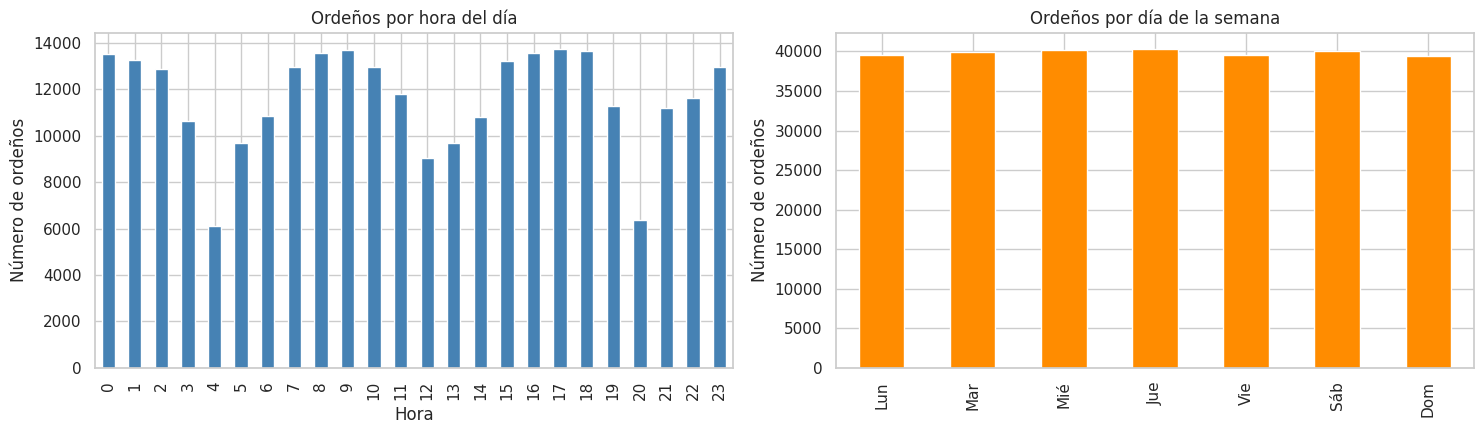

In [241]:
dias = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
df.groupby("hora").size().plot.bar(ax=axes[0], color="steelblue")
axes[0].set(title="Ordeños por hora del día", xlabel="Hora", ylabel="Número de ordeños")

df.groupby("dia_semana").size().rename(index=dict(enumerate(dias))).plot.bar(ax=axes[1], color="darkorange")
axes[1].set(title="Ordeños por día de la semana", xlabel="", ylabel="Número de ordeños")
plt.tight_layout(); plt.show()

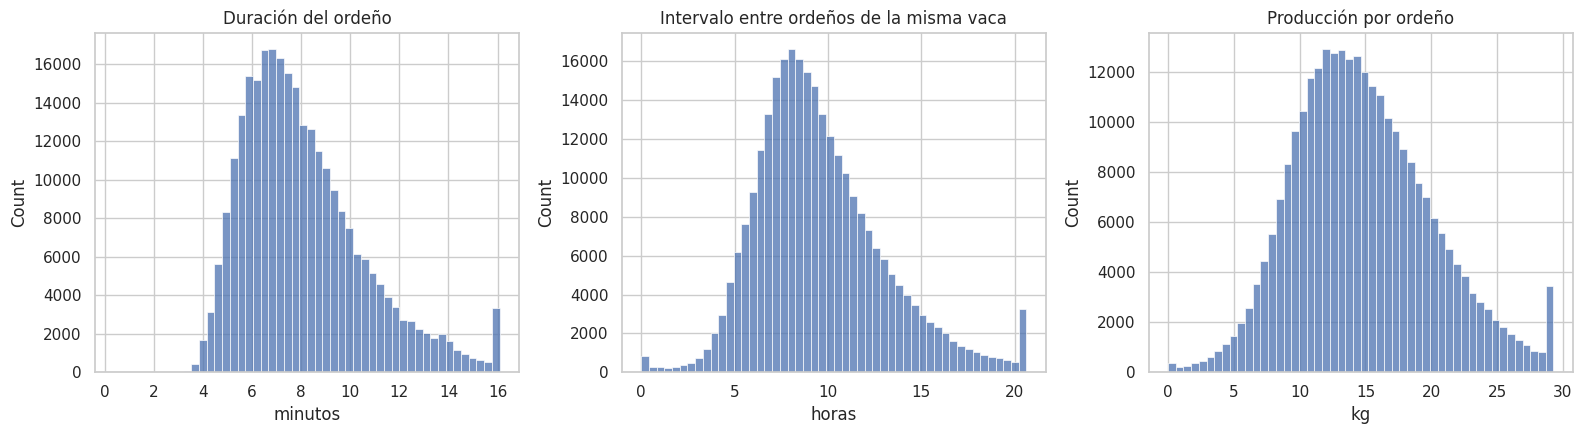

In [242]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.histplot(df["duracion_min"].clip(upper=df["duracion_min"].quantile(.99)), bins=50, ax=axes[0])
axes[0].set(title="Duración del ordeño", xlabel="minutos")
sns.histplot(df["intervalo_min"].clip(upper=df["intervalo_min"].quantile(.99)) / 60, bins=50, ax=axes[1])
axes[1].set(title="Intervalo entre ordeños de la misma vaca", xlabel="horas")
sns.histplot(df["produccion_kg"].clip(upper=df["produccion_kg"].quantile(.99)), bins=50, ax=axes[2])
axes[2].set(title="Producción por ordeño", xlabel="kg")
plt.tight_layout(); plt.show()

## 13. Ocupacion de cada robot por hora

Calculamos que porcentaje de cada hora estuvo ocupado por cada robot, sumando la duracion de los ordeños que empezaron en esa hora

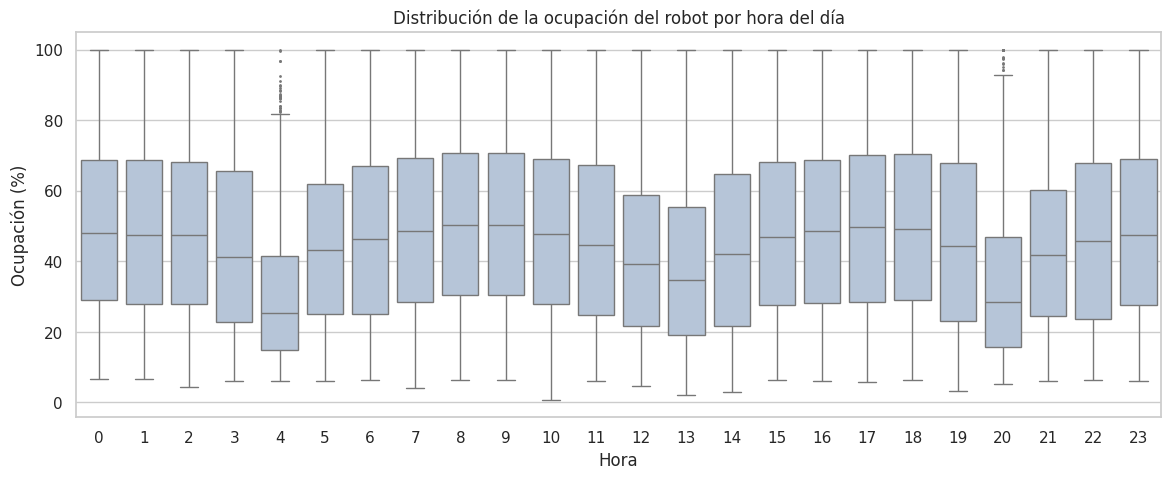

In [243]:
# Minutos de ordeño por robot, fecha y hora
ocup = (df.dropna(subset=["hora_inicio", "ms", "duracion_min"])
          .groupby(["ms", "fecha", "hora"])["duracion_min"].sum()
          .reset_index())
ocup["ocupacion_pct"] = (ocup["duracion_min"] / 60 * 100).clip(upper=100)
ocup["dia_semana"] = pd.to_datetime(ocup["fecha"]).dt.dayofweek

plt.figure(figsize=(14, 5))
sns.boxplot(data=ocup, x="hora", y="ocupacion_pct", color="lightsteelblue", fliersize=1)
plt.title("Distribución de la ocupación del robot por hora del día")
plt.ylabel("Ocupación (%)"); plt.xlabel("Hora"); plt.show()

Ocupacion media del robot para cada combinacion de dia de la semana y hora

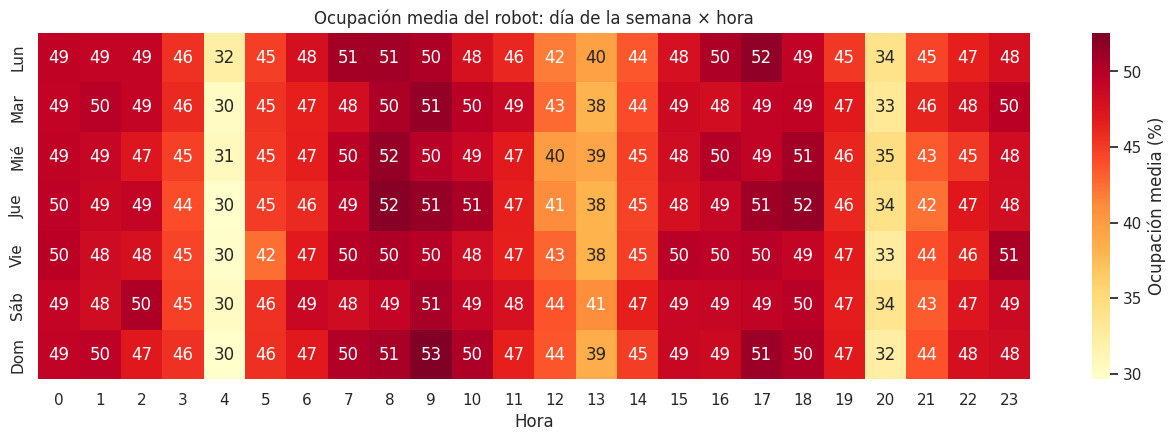

In [244]:
mapa = ocup.pivot_table(index="dia_semana", columns="hora", values="ocupacion_pct", aggfunc="mean")
mapa.index = [dias[i] for i in mapa.index]

plt.figure(figsize=(16, 4.5))
sns.heatmap(mapa, cmap="YlOrRd", annot=True, fmt=".0f", cbar_kws={"label": "Ocupación media (%)"})
plt.title("Ocupación media del robot: día de la semana × hora"); plt.xlabel("Hora"); plt.ylabel("")
plt.show()

In [245]:
# Ocupación media por robot (para ver si algún robot está más saturado que otros)
ocup.groupby("ms")["ocupacion_pct"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
ms,,,,,,,,
VMS 1,27032.0,49.1,24.8,3.9,28.4,48.0,68.2,100.0
VMS 2,26912.0,45.5,25.5,3.3,23.0,43.0,66.5,100.0
VMS 3,27069.0,44.7,24.3,0.8,24.2,42.0,63.2,100.0


## 14. Tiempo libre entre ordeños
Para cada robot se calcula el tiempo libre entre el fin de un ordeño y el incio del siguiente. En el caso de que tenga un valor de 2 minutos o menos, sera marcadabo como posible cola, debido a que lo mas probable es que la siguiente vaca este esperando

In [246]:
UMBRAL_COLA_MIN = 2   # ajustable: ≤ 2 min libres entre ordeños se considera "posible cola"

s = df.dropna(subset=["hora_inicio", "ms", "duracion_min"]).sort_values(["ms", "hora_inicio"]).copy()
s["fin"] = s["hora_inicio"] + pd.to_timedelta(s["duracion_min"], unit="m")
s["siguiente_inicio"] = s.groupby("ms")["hora_inicio"].shift(-1)
s["tiempo_libre_min"] = (s["siguiente_inicio"] - s["fin"]).dt.total_seconds() / 60

# Valores negativos = traslapes (posibles errores de registro o duplicados)
print(f"Traslapes (tiempo libre < 0): {(s['tiempo_libre_min'] < 0).sum():,}")
s = s[s["tiempo_libre_min"].between(0, 24 * 60)]
s["posible_cola"] = s["tiempo_libre_min"] <= UMBRAL_COLA_MIN

print(f"Ordeños seguidos de otro en ≤ {UMBRAL_COLA_MIN} min: {s['posible_cola'].mean():.1%}")
s["tiempo_libre_min"].describe(percentiles=[.1, .25, .5, .75, .9]).round(2)

Traslapes (tiempo libre < 0): 2
Ordeños seguidos de otro en ≤ 2 min: 53.7%


,tiempo_libre_min
count,278961.00
mean,11.96
std,25.62
min,0.10
10%,0.38
25%,0.48
50%,1.22
75%,12.12
90%,34.02
max,709.03


El histograma muestra como se distribuye el tiempo libre entre ordeños junto con el umbral elegido, por el contrario la grafica de barras indica que horas del dia es mas frecuente que haya cola.

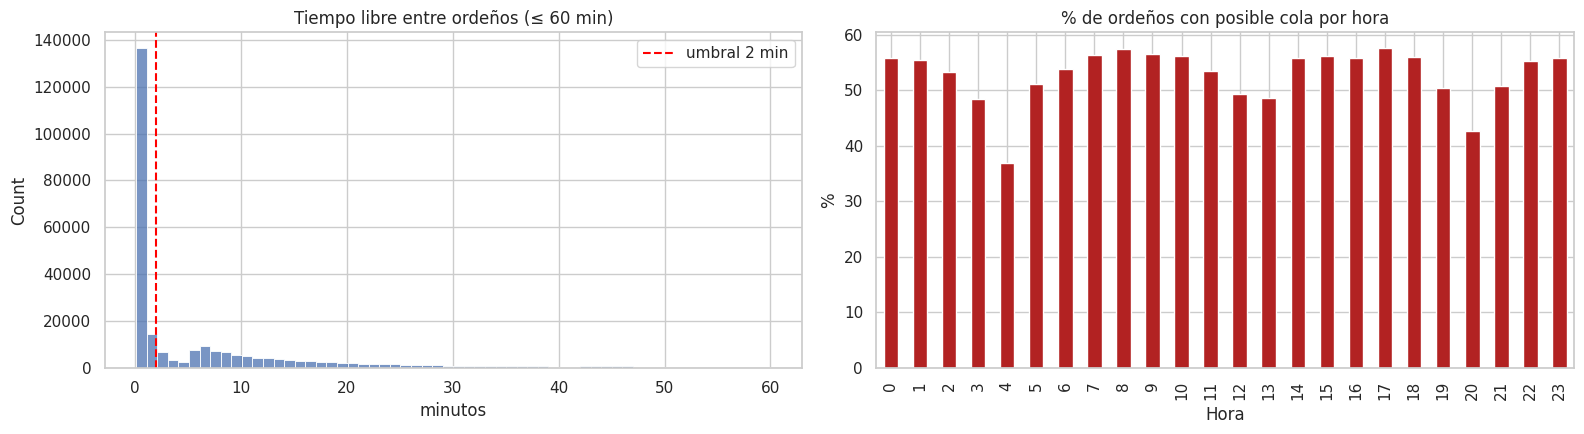

In [247]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
sns.histplot(s.loc[s["tiempo_libre_min"] <= 60, "tiempo_libre_min"], bins=60, ax=axes[0])
axes[0].axvline(UMBRAL_COLA_MIN, color="red", ls="--", label=f"umbral {UMBRAL_COLA_MIN} min")
axes[0].set(title="Tiempo libre entre ordeños (≤ 60 min)", xlabel="minutos"); axes[0].legend()

(s.groupby("hora")["posible_cola"].mean() * 100).plot.bar(ax=axes[1], color="firebrick")
axes[1].set(title="% de ordeños con posible cola por hora", xlabel="Hora", ylabel="%")
plt.tight_layout(); plt.show()

Mostramos el porcentaje de ordeños con posible cola para cada combinación de día de la semana y hora, para ubicar los momentos más críticos.

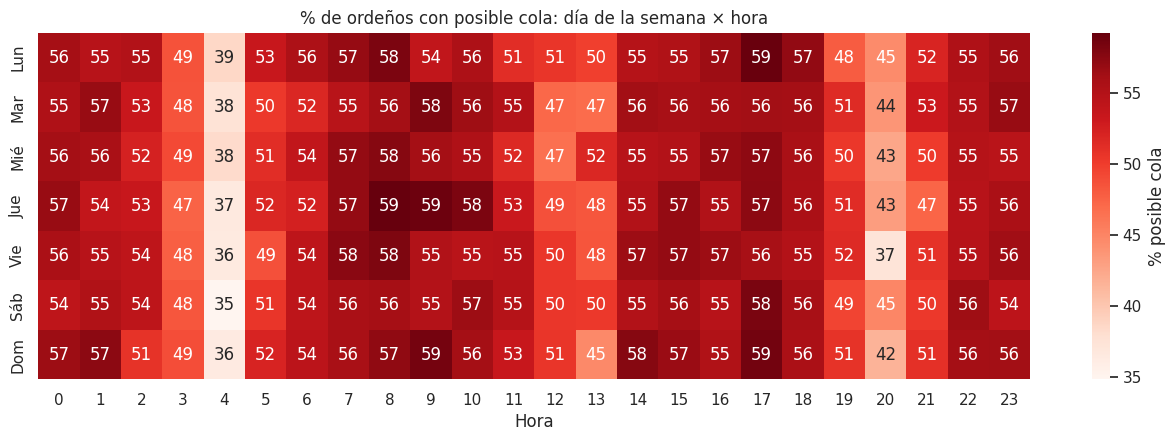

In [248]:
mapa_cola = s.pivot_table(index="dia_semana", columns="hora", values="posible_cola", aggfunc="mean") * 100
mapa_cola.index = [dias[i] for i in mapa_cola.index]

plt.figure(figsize=(16, 4.5))
sns.heatmap(mapa_cola, cmap="Reds", annot=True, fmt=".0f", cbar_kws={"label": "% posible cola"})
plt.title("% de ordeños con posible cola: día de la semana × hora"); plt.xlabel("Hora"); plt.ylabel("")
plt.show()

## 15. Condiciones operativas asociadas a la posible cola

Convertimos las incidencias del ordeno en variables binarias y comparamos sus promedios, junto con la duracion, intervalo y produccion entre los ordenos que fueron seguidos de una posible cola y los que no.

In [249]:
# Incidencias del ordeño como variables binarias
for col in ["patada", "incompleto", "pezones_no_encontrados"]:
    if col in s.columns:
        s[f"tiene_{col}"] = s[col].notna()

comparar = ["duracion_min", "intervalo_min", "Producción (kg)",
            "tiene_patada", "tiene_incompleto", "tiene_pezones_no_encontrados"]
comparar = [c for c in comparar if c in s.columns]

print("Promedios según si hubo posible cola después del ordeño:")
s.groupby("posible_cola")[comparar].mean().T.round(3)

Promedios según si hubo posible cola después del ordeño:


posible_cola,False,True
duracion_min,8.072,8.121
intervalo_min,574.286,574.224
tiene_patada,0.167,0.155
tiene_incompleto,0.143,0.100


Correlacion entre variables numericas y el indicador de posible cola para identificar cuales se relacionan mas con la formacion de colas.

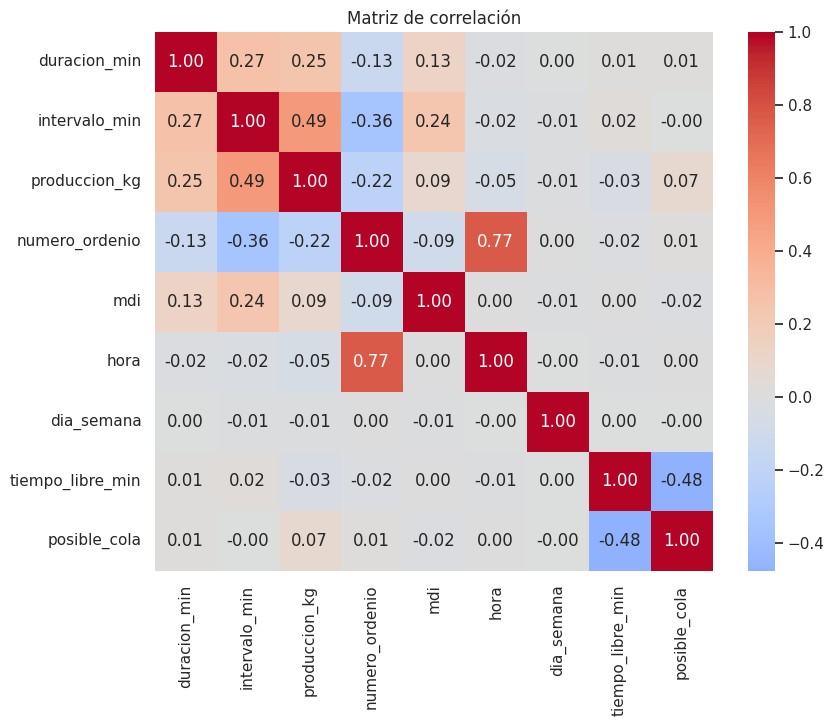

In [250]:
# Correlación entre variables numéricas y los indicadores de cola
num = ["duracion_min", "intervalo_min", "produccion_kg", "numero_ordenio", "mdi",
       "hora", "dia_semana", "tiempo_libre_min", "posible_cola"]
num = [c for c in num if c in s.columns]

plt.figure(figsize=(9, 7))
sns.heatmap(s[num].astype(float).corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación"); plt.show()

Se cuentan que vacas entran al robot con mas frecuencia justo despues de otro ordeno, en otras palabras son las que mas probablemente estuvieron en la fila.

In [251]:
# Vacas que con más frecuencia entran justo después de otra (posible espera en cola)
por_vaca = (s.assign(siguiente_vaca=s.groupby("ms")["id_vaca"].shift(-1))
              .loc[lambda d: d["posible_cola"]]
              .groupby("siguiente_vaca").size()
              .sort_values(ascending=False))
print("Top 10 vacas que entran con ≤ 2 min de espacio tras otro ordeño:")
por_vaca.head(10).to_frame("veces")

Top 10 vacas que entran con ≤ 2 min de espacio tras otro ordeño:


,veces
siguiente_vaca,
1557,1511
6208,1482
6122,1441
6119,1435
6036,1411
6181,1406
6161,1389
1623,1387
1555,1381


## 16. Periodos sin registro

En esta seccion buscamos los momentos en los que no hay registros de ordeño. Se separan en cuatro tipos porque cada uno significa algo distinto:

1. **Dias completos sin registros por robot:** posible falla, mantenimiento o perdida en la exportacion de datos.
2. **Horas sin actividad dentro del dia:** huecos largos entre un ordeño y el siguiente en el mismo robot.
3. **Cobertura por vaca:** el historial solo incluye a las vacas que estan actualmente en el establo, por lo que los primeros meses tienen menos vacas.
4. **Huecos por vaca:** dias en los que una vaca no se ordeña (por ejemplo el periodo de secado de ~60 dias).

### 16.1 Dias sin registros por robot

Creamos un calendario con todos los dias del periodo y contamos cuantos ordeños tuvo cada robot por dia. Los dias con 0 registros se agrupan en rangos consecutivos para ver cuanto duro cada hueco. Tambien marcamos los dias con actividad anormalmente baja (menos del 25 % de la mediana de los 30 dias anteriores), que pueden indicar un dia incompleto.

In [252]:
calendario = pd.date_range(df["hora_inicio"].min().normalize(), df["hora_inicio"].max().normalize(), freq="D")

registros_dia = (df.dropna(subset=["ms"])
                   .assign(dia=lambda d: d["hora_inicio"].dt.normalize())
                   .groupby(["dia", "ms"]).size()
                   .unstack("ms", fill_value=0)
                   .reindex(calendario, fill_value=0))

def rangos_consecutivos(fechas):
    """Agrupa una lista de fechas en rangos de dias consecutivos (inicio, fin, dias)."""
    fechas = pd.Series(sorted(fechas))
    if fechas.empty:
        return pd.DataFrame(columns=["inicio", "fin", "dias"])
    grupo = (fechas.diff().dt.days != 1).cumsum()
    return (fechas.groupby(grupo).agg(inicio="min", fin="max", dias="size").reset_index(drop=True))

print(f"Dias en el periodo: {len(calendario):,}\n")
for robot in registros_dia.columns:
    sin_registro = registros_dia.index[registros_dia[robot] == 0]
    print(f"{robot}: {len(sin_registro)} dias sin registros")
    rangos = rangos_consecutivos(sin_registro)
    if not rangos.empty:
        display(rangos.sort_values("dias", ascending=False).head(10))

todos_cero = registros_dia.index[(registros_dia == 0).all(axis=1)]
print(f"Dias sin registros en los 3 robots al mismo tiempo: {len(todos_cero)}")
if len(todos_cero):
    display(rangos_consecutivos(todos_cero))

Dias en el periodo: 1,296

VMS 1: 0 dias sin registros
VMS 2: 0 dias sin registros
VMS 3: 0 dias sin registros
Dias sin registros en los 3 robots al mismo tiempo: 0


Dias con actividad < 25 % de la mediana de los 30 dias anteriores:


,dias
ms,
VMS 1,1
VMS 2,0
VMS 3,0


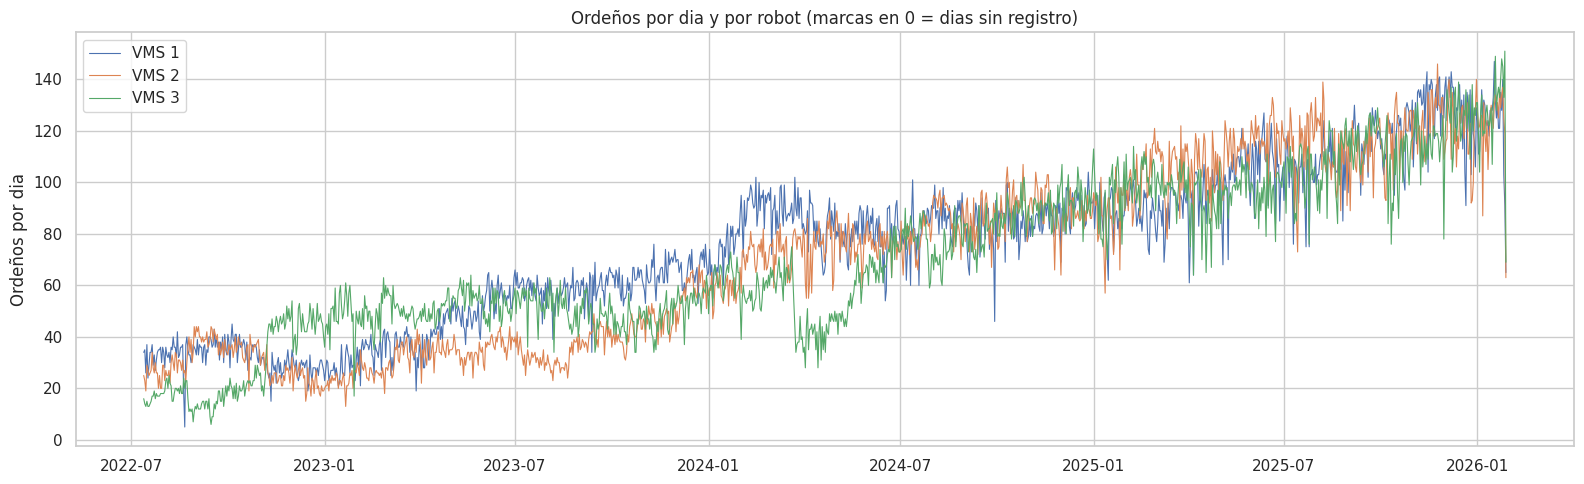

In [253]:
# Dias con actividad anormalmente baja (posibles dias incompletos)
referencia = registros_dia.rolling(30, min_periods=7).median().shift(1)
dias_bajos = (registros_dia > 0) & (registros_dia < 0.25 * referencia)
print("Dias con actividad < 25 % de la mediana de los 30 dias anteriores:")
display(dias_bajos.sum().to_frame("dias"))

fig, ax = plt.subplots(figsize=(16, 5))
for robot in registros_dia.columns:
    ax.plot(registros_dia.index, registros_dia[robot], lw=0.8, label=robot)
    ceros = registros_dia.index[registros_dia[robot] == 0]
    ax.scatter(ceros, [0] * len(ceros), marker="|", s=200)
ax.set(title="Ordeños por dia y por robot (marcas en 0 = dias sin registro)", xlabel="", ylabel="Ordeños por dia")
ax.legend(); plt.tight_layout(); plt.show()

### 16.2 Horas sin actividad (huecos dentro del dia)

Calculamos el tiempo entre el fin de un ordeño y el inicio del siguiente en el mismo robot, **sin** el filtro de 24 h que se uso en la seccion 14, y nos quedamos con los huecos mayores a 60 min. Despues revisamos en que hora empiezan y si coinciden con un programa de lavado.

Ademas construimos una malla de todas las horas del periodo para contar las horas sin ningun ordeño por robot y las horas en las que **los 3 robots** estuvieron sin actividad al mismo tiempo. Si los 3 robots se detienen a la vez es mas probable que sea un corte de luz o de datos que un comportamiento de las vacas.

In [254]:
UMBRAL_HUECO_MIN = 60   # ajustable: tiempo sin ordeños que se considera un hueco

g = df.dropna(subset=["hora_inicio", "ms", "duracion_min"]).sort_values(["ms", "hora_inicio"]).copy()
g["fin"] = g["hora_inicio"] + pd.to_timedelta(g["duracion_min"], unit="m")
g["siguiente_inicio"] = g.groupby("ms")["hora_inicio"].shift(-1)
g["hueco_min"] = (g["siguiente_inicio"] - g["fin"]).dt.total_seconds() / 60

huecos = g.loc[g["hueco_min"] > UMBRAL_HUECO_MIN, ["ms", "fin", "siguiente_inicio", "hueco_min", "programa_lavado"]]
print(f"Huecos > {UMBRAL_HUECO_MIN} min: {len(huecos):,}")
display(huecos.groupby("ms")["hueco_min"].describe(percentiles=[.5, .9, .99]).round(1))

print("Huecos mas largos:")
display(huecos.sort_values("hueco_min", ascending=False).head(15))

# ¿Los huecos coinciden con un programa de lavado?
print(f"% de ordeños con programa de lavado (general): {g['programa_lavado'].notna().mean():.1%}")
print(f"% de ordeños con programa de lavado antes de un hueco: {huecos['programa_lavado'].notna().mean():.1%}")

Huecos > 60 min: 12,685


,count,mean,std,min,50%,90%,99%,max
ms,,,,,,,,
VMS 1,4121.0,98.7,52.7,60.0,81.7,154.5,300.8,709.0
VMS 2,4468.0,103.7,51.3,60.0,86.7,162.0,300.6,601.7
VMS 3,4096.0,104.4,55.7,60.0,85.6,169.0,336.7,501.0


Huecos mas largos:


,ms,fin,siguiente_inicio,hueco_min,programa_lavado
7439,VMS 1,2022-12-16 16:29:32.999999998,2022-12-17 04:18:35,709.033333,NaN
31880,VMS 1,2025-12-20 20:07:45.000000000,2025-12-21 07:26:55,679.166667,NaN
16179,VMS 1,2022-08-21 13:51:26.999999997,2022-08-22 00:34:09,642.700000,NaN
68181,VMS 1,2023-02-04 04:56:52.000000000,2023-02-04 15:24:03,627.183333,NaN
188840,VMS 2,2023-01-05 13:18:02.000000002,2023-01-05 23:19:44,601.700000,NaN
20604,VMS 1,2023-01-20 01:27:44.000000000,2023-01-20 11:09:50,582.100000,NaN
43474,VMS 1,2022-07-14 19:19:15.999999998,2022-07-15 04:51:47,572.516667,NaN
34111,VMS 1,2022-08-21 04:06:34.999999998,2022-08-21 13:34:25,567.833333,NaN
158823,VMS 2,2022-12-28 14:13:07.000000000,2022-12-28 23:32:27,559.333333,NaN
181381,VMS 1,2022-11-11 00:35:26.999999998,2022-11-11 09:24:39,529.200000,NaN


% de ordeños con programa de lavado (general): 5.6%
% de ordeños con programa de lavado antes de un hueco: 8.7%


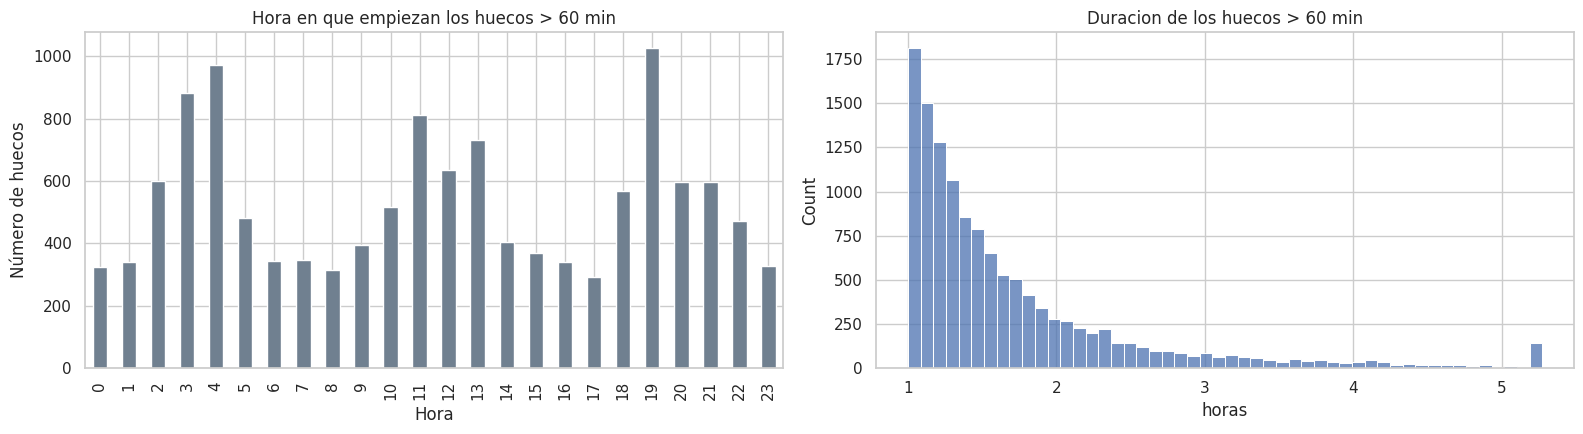

In [255]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
huecos["fin"].dt.hour.value_counts().reindex(range(24), fill_value=0).plot.bar(ax=axes[0], color="slategray")
axes[0].set(title=f"Hora en que empiezan los huecos > {UMBRAL_HUECO_MIN} min", xlabel="Hora", ylabel="Número de huecos")

sns.histplot(huecos["hueco_min"].clip(upper=huecos["hueco_min"].quantile(.99)) / 60, bins=50, ax=axes[1])
axes[1].set(title=f"Duracion de los huecos > {UMBRAL_HUECO_MIN} min", xlabel="horas")
plt.tight_layout(); plt.show()

,horas_sin_ordeño,% del periodo
ms,,
VMS 1,4060,13.06
VMS 2,4180,13.44
VMS 3,4023,12.94


Horas sin actividad en los 3 robots al mismo tiempo: 946 (3.04% del periodo)


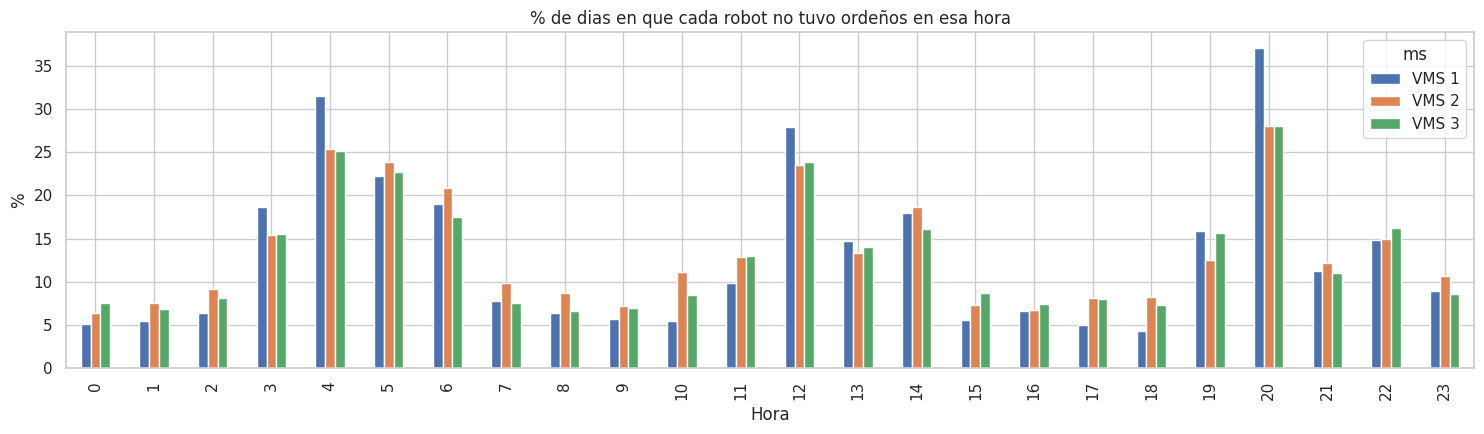

In [256]:
# Malla de todas las horas del periodo: horas sin ningun ordeño por robot
horas = pd.date_range(df["hora_inicio"].min().floor("h"), df["hora_inicio"].max().floor("h"), freq="h")
ordenios_hora = (df.dropna(subset=["ms"])
                  .assign(h=lambda d: d["hora_inicio"].dt.floor("h"))
                  .groupby(["h", "ms"]).size()
                  .unstack("ms", fill_value=0)
                  .reindex(horas, fill_value=0))

resumen_horas = pd.DataFrame({
    "horas_sin_ordeño": (ordenios_hora == 0).sum(),
    "% del periodo": ((ordenios_hora == 0).mean() * 100).round(2),
})
display(resumen_horas)

sin_actividad_total = ordenios_hora.index[(ordenios_hora == 0).all(axis=1)]
print(f"Horas sin actividad en los 3 robots al mismo tiempo: {len(sin_actividad_total):,} "
      f"({len(sin_actividad_total) / len(horas):.2%} del periodo)")

# Horas sin ordeño por hora del dia (para ver si hay una hora fija de paro)
(ordenios_hora == 0).groupby(ordenios_hora.index.hour).mean().mul(100).plot.bar(figsize=(15, 4.5))
plt.title("% de dias en que cada robot no tuvo ordeños en esa hora"); plt.xlabel("Hora"); plt.ylabel("%")
plt.tight_layout(); plt.show()

### 16.3 Cobertura por vaca

El numero de registros por mes crece mucho entre 2022 y 2025. Para saber si esto se debe a que hay mas actividad o a que el historial solo incluye a las vacas actuales, comparamos el numero de vacas activas (vacas distintas con al menos un ordeño en el mes) contra los registros, y revisamos la fecha del primer y ultimo registro de cada vaca.

mes,2022-07,2022-08,2022-09,2022-10,2022-11,2022-12,2023-01,2023-02,2023-03,2023-04,...,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01
registros,1406.0,2530.0,2667.0,2867.0,2855.0,2979.0,3075.0,3081.0,3716.0,3764.0,...,8629.0,9715.0,9634.0,9867.0,10153.0,10400.0,10616.0,11088.0,11559.0,10414.0
vacas_activas,34.0,37.0,42.0,46.0,48.0,49.0,52.0,55.0,56.0,58.0,...,141.0,137.0,145.0,145.0,148.0,153.0,163.0,169.0,172.0,182.0
ordeños_por_vaca,41.4,68.4,63.5,62.3,59.5,60.8,59.1,56.0,66.4,64.9,...,61.2,70.9,66.4,68.0,68.6,68.0,65.1,65.6,67.2,57.2


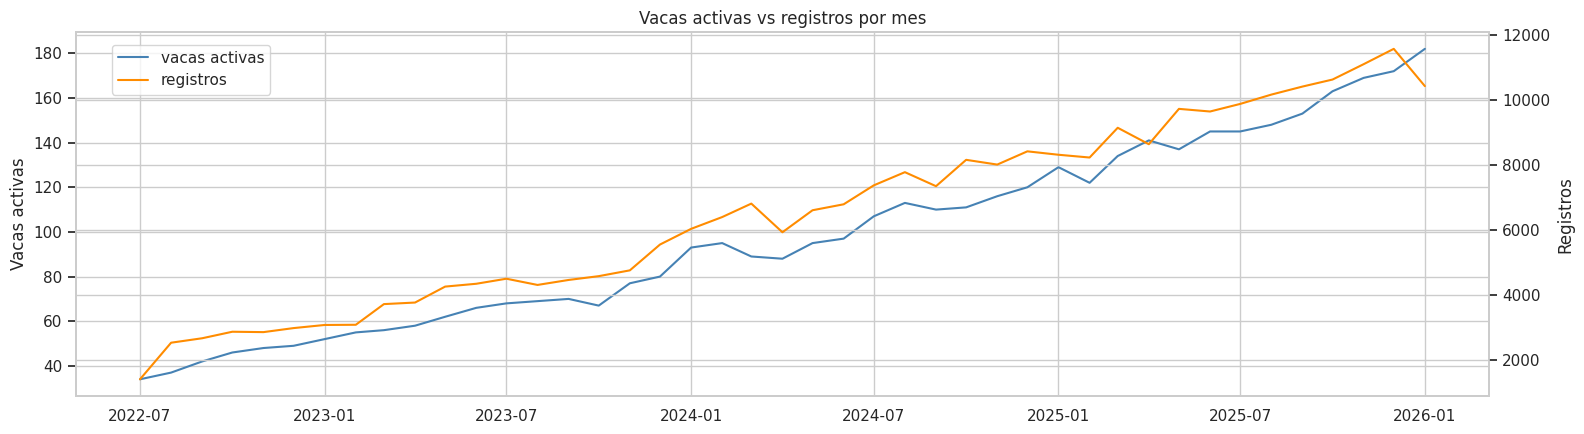

In [257]:
cobertura = df.groupby("mes").agg(registros=("id_vaca", "size"), vacas_activas=("id_vaca", "nunique"))
cobertura["ordeños_por_vaca"] = (cobertura["registros"] / cobertura["vacas_activas"]).round(1)
display(cobertura.T)

fig, ax1 = plt.subplots(figsize=(16, 4.5))
x = cobertura.index.to_timestamp()
ax1.plot(x, cobertura["vacas_activas"], color="steelblue", label="vacas activas")
ax1.set_ylabel("Vacas activas")
ax2 = ax1.twinx()
ax2.plot(x, cobertura["registros"], color="darkorange", label="registros")
ax2.set_ylabel("Registros")
ax1.set_title("Vacas activas vs registros por mes")
fig.legend(loc="upper left", bbox_to_anchor=(0.07, 0.9)); plt.tight_layout(); plt.show()

,count,mean,min,25%,50%,75%,max,std
primer_registro,201,2024-03-04 09:59:50.412935424,2022-07-13 00:05:28,2022-11-18 15:13:08,2024-05-13 18:20:27,2025-03-18 09:36:30,2026-01-26 10:34:27,NaN
ultimo_registro,201,2026-01-20 00:39:06.800995328,2025-10-03 03:59:25,2026-01-28 00:32:29,2026-01-28 05:43:55,2026-01-28 08:39:40,2026-01-28 11:47:54,NaN
ordeños,201.0,1387.900498,2.0,585.0,1274.0,2187.0,3569.0,912.360625
dias_con_historial,201.0,686.029851,1.0,300.0,624.0,1155.0,1295.0,436.455403


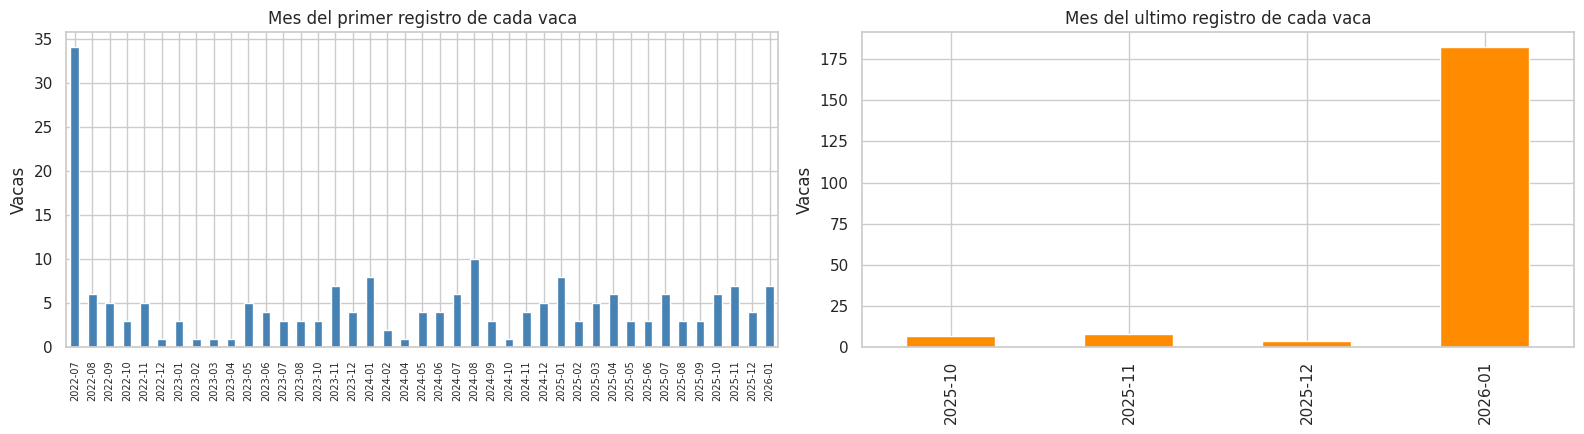

In [258]:
# Primer y ultimo registro de cada vaca
vida_vaca = df.groupby("id_vaca")["hora_inicio"].agg(primer_registro="min", ultimo_registro="max", ordeños="size")
vida_vaca["dias_con_historial"] = (vida_vaca["ultimo_registro"] - vida_vaca["primer_registro"]).dt.days
display(vida_vaca.describe().T)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
vida_vaca["primer_registro"].dt.to_period("M").value_counts().sort_index().plot.bar(ax=axes[0], color="steelblue")
axes[0].set(title="Mes del primer registro de cada vaca", xlabel="", ylabel="Vacas")
axes[0].tick_params(axis="x", labelsize=7)
vida_vaca["ultimo_registro"].dt.to_period("M").value_counts().sort_index().plot.bar(ax=axes[1], color="darkorange")
axes[1].set(title="Mes del ultimo registro de cada vaca", xlabel="", ylabel="Vacas")
plt.tight_layout(); plt.show()

### 16.4 Huecos por vaca

La columna `intervalo_ordenio` tiene un maximo de 1439.95 min (justo 24 h), por lo que parece que el formato hh:mm no guarda intervalos mayores a un dia. Por eso calculamos los dias sin ordeño de cada vaca directamente con las fechas. Los huecos de ~60 dias corresponden al periodo de secado, mientras que los huecos de pocos dias pueden ser vacas en el corral de atencion o registros faltantes.

Intervalos reales mayores a 24 h: 2,849
Intervalos de la columna original mayores a 24 h: 0

Huecos por vaca segun su duracion:


,huecos
dias_sin_ordeño,
1-2 dias,2433
2-7 dias,119
7-30 dias,41
30-45 dias,8
45-90 dias (secado),160
> 90 dias,88


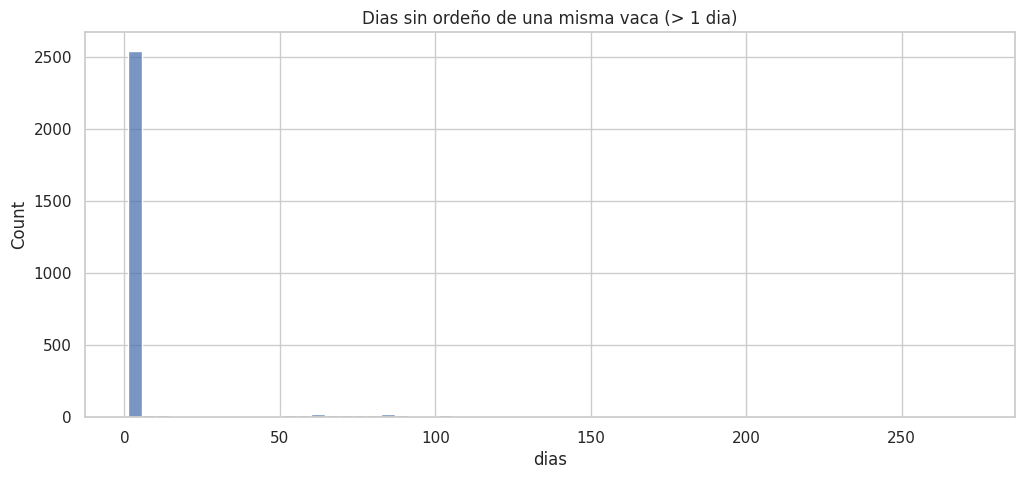

In [259]:
v = df.sort_values(["id_vaca", "hora_inicio"]).copy()
v["dias_sin_ordeño"] = v.groupby("id_vaca")["hora_inicio"].diff().dt.total_seconds() / 86400

# Comparacion con la columna original de intervalo
v["intervalo_real_min"] = v["dias_sin_ordeño"] * 24 * 60
print(f"Intervalos reales mayores a 24 h: {(v['intervalo_real_min'] > 24 * 60).sum():,}")
print(f"Intervalos de la columna original mayores a 24 h: {(v['intervalo_min'] > 24 * 60).sum():,}\n")

rangos_hueco = pd.cut(v["dias_sin_ordeño"], bins=[1, 2, 7, 30, 45, 90, np.inf],
                      labels=["1-2 dias", "2-7 dias", "7-30 dias", "30-45 dias", "45-90 dias (secado)", "> 90 dias"])
print("Huecos por vaca segun su duracion:")
display(rangos_hueco.value_counts().sort_index().to_frame("huecos"))

sns.histplot(v.loc[v["dias_sin_ordeño"] > 1, "dias_sin_ordeño"], bins=60)
plt.title("Dias sin ordeño de una misma vaca (> 1 dia)"); plt.xlabel("dias"); plt.show()

### 16.5 Secado por vaca y vacas con dias sin ordeño por año

No existe una columna que indique el secado, por lo que lo identificamos a partir de los huecos de cada vaca: si una vaca pasa **40 dias o mas** sin ordeñarse lo consideramos un secado, y los huecos de mas de 1 dia pero menores a ese umbral se toman como huecos cortos (corral de atencion, registros faltantes, etc.).

Una lactancia dura ~305 dias y el secado ~60 dias, por lo que solo esperamos ver al menos un secado en las vacas con **un año o mas de historial**. Las vacas con menos historial que no muestran secado son normales; las que tienen un año o mas y no muestran ningun secado deben revisarse.

Al final contamos, por año, cuantas vacas tuvieron al menos un dia sin ordeño y cuantas tuvieron un secado. El año del hueco se toma segun la fecha en que empezo.

In [260]:
UMBRAL_SECADO_DIAS = 40   # ajustable: huecos de este tamaño o mayores se consideran secado

huecos_vaca = v.loc[v["dias_sin_ordeño"] > 1, ["id_vaca", "hora_inicio", "dias_sin_ordeño"]].copy()
huecos_vaca["inicio_hueco"] = huecos_vaca["hora_inicio"] - pd.to_timedelta(huecos_vaca["dias_sin_ordeño"], unit="D")
huecos_vaca["año"] = huecos_vaca["inicio_hueco"].dt.year
huecos_vaca["tipo"] = np.where(huecos_vaca["dias_sin_ordeño"] >= UMBRAL_SECADO_DIAS, "secado", "hueco corto")

# Resumen por vaca
secado_vaca = vida_vaca[["primer_registro", "ultimo_registro", "dias_con_historial"]].copy()
secado_vaca["huecos_cortos"] = huecos_vaca[huecos_vaca["tipo"] == "hueco corto"].groupby("id_vaca").size()
secado_vaca["secados"] = huecos_vaca[huecos_vaca["tipo"] == "secado"].groupby("id_vaca").size()
secado_vaca[["huecos_cortos", "secados"]] = secado_vaca[["huecos_cortos", "secados"]].fillna(0).astype(int)
secado_vaca["dias_secado_promedio"] = (huecos_vaca[huecos_vaca["tipo"] == "secado"]
                                       .groupby("id_vaca")["dias_sin_ordeño"].mean().round(1))

secado_vaca["situacion"] = np.select(
    [secado_vaca["secados"] > 0, secado_vaca["dias_con_historial"] < 365],
    ["con secado registrado", "sin secado (historial < 1 año, normal)"],
    default="sin secado (historial ≥ 1 año, revisar)")

print(f"Vacas totales: {len(secado_vaca)}")
display(secado_vaca["situacion"].value_counts().to_frame("vacas"))
print("Secados por vaca:")
display(secado_vaca["secados"].value_counts().sort_index().to_frame("vacas"))
print("Duracion de los secados (dias):")
display(huecos_vaca.loc[huecos_vaca["tipo"] == "secado", "dias_sin_ordeño"].describe().round(1).to_frame().T)

Vacas totales: 201


,vacas
situacion,
con secado registrado,133
"sin secado (historial < 1 año, normal)",61
"sin secado (historial ≥ 1 año, revisar)",7


Secados por vaca:


,vacas
secados,
0,68
1,53
2,45
3,32
4,3


Duracion de los secados (dias):


,count,mean,std,min,25%,50%,75%,max
dias_sin_ordeño,251.0,86.9,33.5,40.4,63.8,81.4,99.5,272.9


Periodo: 2022-07-13 a 2026-01-28 (el primer y ultimo año estan incompletos)


,vacas_activas,vacas_con_dias_sin_ordeño,vacas_con_hueco_corto,vacas_con_secado,total_dias_sin_ordeño,% vacas con dias sin ordeño,% vacas con secado
año,,,,,,,
2022,54,51,48,21,1709,94.4,38.9
2023,89,87,85,46,4185,97.8,51.7
2024,137,129,109,82,8707,94.2,59.9
2025,194,177,160,98,11063,91.2,50.5
2026,182,61,61,0,179,33.5,0.0


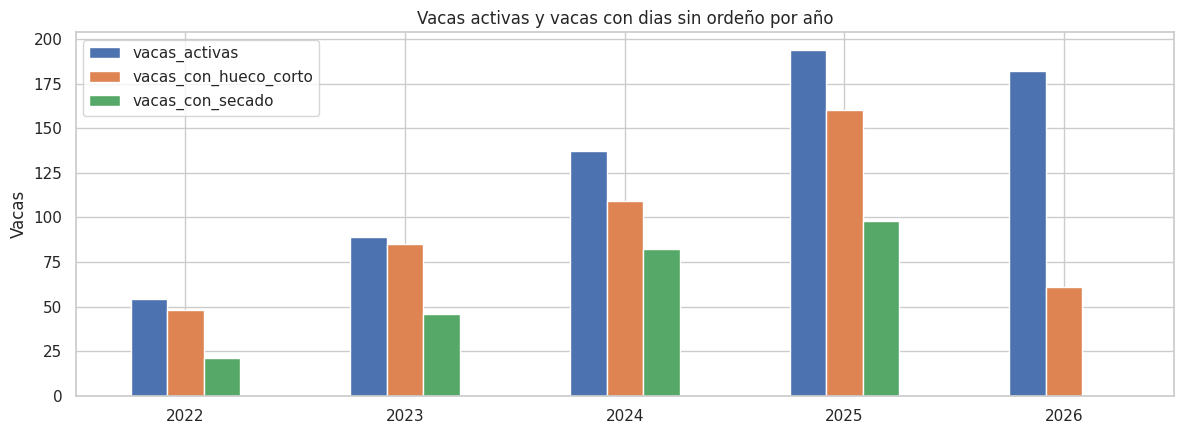

In [261]:
# Vacas con dias sin ordeño por año
vacas_año = df.groupby(df["hora_inicio"].dt.year)["id_vaca"].nunique()
por_año = pd.DataFrame({
    "vacas_activas": vacas_año,
    "vacas_con_dias_sin_ordeño": huecos_vaca.groupby("año")["id_vaca"].nunique(),
    "vacas_con_hueco_corto": huecos_vaca[huecos_vaca["tipo"] == "hueco corto"].groupby("año")["id_vaca"].nunique(),
    "vacas_con_secado": huecos_vaca[huecos_vaca["tipo"] == "secado"].groupby("año")["id_vaca"].nunique(),
    "total_dias_sin_ordeño": huecos_vaca.groupby("año")["dias_sin_ordeño"].sum().round(0),
}).fillna(0)
por_año.index.name = "año"
por_año = por_año.astype(int)
por_año["% vacas con dias sin ordeño"] = (por_año["vacas_con_dias_sin_ordeño"] / por_año["vacas_activas"] * 100).round(1)
por_año["% vacas con secado"] = (por_año["vacas_con_secado"] / por_año["vacas_activas"] * 100).round(1)

print(f"Periodo: {df['hora_inicio'].min():%Y-%m-%d} a {df['hora_inicio'].max():%Y-%m-%d} "
      f"(el primer y ultimo año estan incompletos)")
display(por_año)

ax = por_año[["vacas_activas", "vacas_con_hueco_corto", "vacas_con_secado"]].plot.bar(figsize=(12, 4.5), rot=0)
ax.set(title="Vacas activas y vacas con dias sin ordeño por año", xlabel="", ylabel="Vacas")
plt.tight_layout(); plt.show()

## 17. Distribuciones por robot y valores atipicos

Comparamos la distribucion de la duracion, la produccion y el tiempo libre entre los tres robots para ver si alguno es mas lento o se usa diferente. Despues contamos los valores atipicos con el criterio IQR (fuera de Q1 − 1.5·IQR y Q3 + 1.5·IQR) y los valores en cero que no tienen sentido fisico (ordeño sin produccion o intervalo de 0 min).

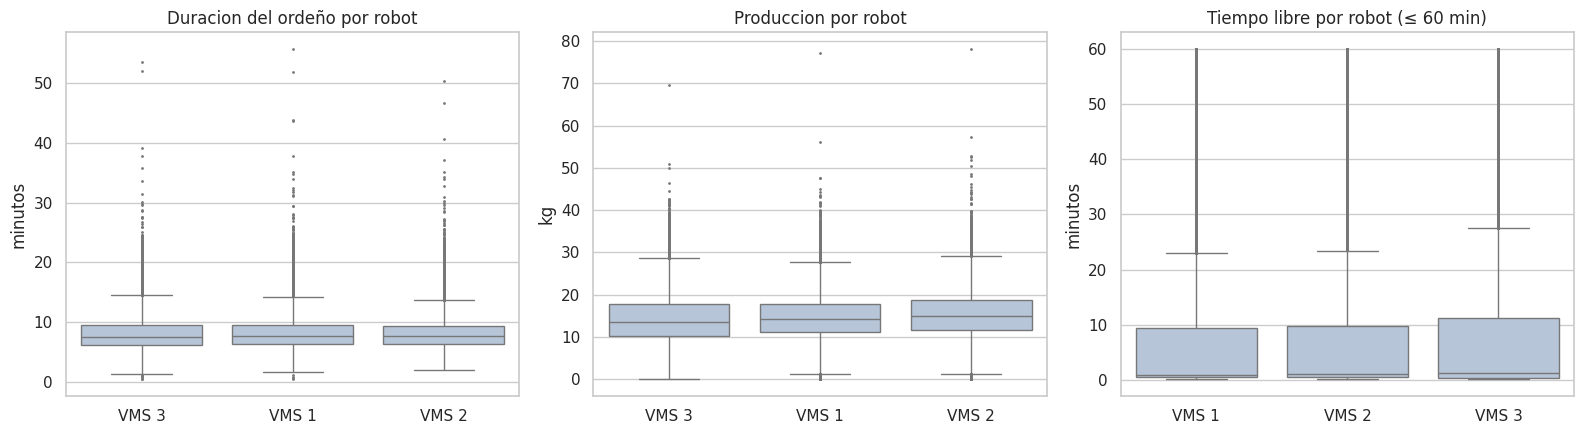

,duracion_min,produccion_kg
ms,,
VMS 1,7.67,14.19
VMS 2,7.58,15.00
VMS 3,7.55,13.66


In [262]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.boxplot(data=df.dropna(subset=["ms"]), x="ms", y="duracion_min", ax=axes[0], fliersize=1, color="lightsteelblue")
axes[0].set(title="Duracion del ordeño por robot", xlabel="", ylabel="minutos")
sns.boxplot(data=df.dropna(subset=["ms"]), x="ms", y="produccion_kg", ax=axes[1], fliersize=1, color="lightsteelblue")
axes[1].set(title="Produccion por robot", xlabel="", ylabel="kg")
sns.boxplot(data=s[s["tiempo_libre_min"] <= 60], x="ms", y="tiempo_libre_min", ax=axes[2], fliersize=1, color="lightsteelblue")
axes[2].set(title="Tiempo libre por robot (≤ 60 min)", xlabel="", ylabel="minutos")
plt.tight_layout(); plt.show()

df.groupby("ms")[["duracion_min", "produccion_kg"]].median().round(2)

In [263]:
# Valores atipicos con criterio IQR y valores en cero
def resumen_atipicos(data, columnas):
    filas = []
    for col in columnas:
        x = data[col].dropna()
        q1, q3 = x.quantile([.25, .75])
        iqr = q3 - q1
        lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        filas.append({
            "variable": col,
            "lim_inferior": round(lim_inf, 2),
            "lim_superior": round(lim_sup, 2),
            "debajo": (x < lim_inf).sum(),
            "encima": (x > lim_sup).sum(),
            "% atipicos": round(((x < lim_inf) | (x > lim_sup)).mean() * 100, 2),
            "ceros": (x == 0).sum(),
        })
    return pd.DataFrame(filas).set_index("variable")

display(resumen_atipicos(df, ["duracion_min", "intervalo_min", "produccion_kg", "mdi"]))

print(f"Ordeños con duracion < 1 min: {(df['duracion_min'] < 1).sum():,}")
print(f"Ordeños con duracion > 30 min: {(df['duracion_min'] > 30).sum():,}")
print(f"Ordeños con produccion = 0 kg: {(df['produccion_kg'] == 0).sum():,}")
print(f"Ordeños con intervalo = 0 min: {(df['intervalo_min'] == 0).sum():,}")

,lim_inferior,lim_superior,debajo,encima,% atipicos,ceros
variable,,,,,,
duracion_min,1.52,14.12,13,7662,2.75,0
intervalo_min,57.14,1060.81,1178,8029,3.30,403
produccion_kg,0.52,28.65,339,3483,1.37,165
mdi,0.87,1.37,90,35159,13.70,0


Ordeños con duracion < 1 min: 8
Ordeños con duracion > 30 min: 31
Ordeños con produccion = 0 kg: 165
Ordeños con intervalo = 0 min: 403


Acercamiento al tiempo libre menor a 5 minutos. Si existe un pico muy marcado cerca de 0.4 min, ese valor probablemente es el tiempo minimo que tarda el robot entre una vaca y otra (salida, limpieza y entrada), lo cual ayuda a justificar el umbral de 2 min usado para marcar una posible cola.

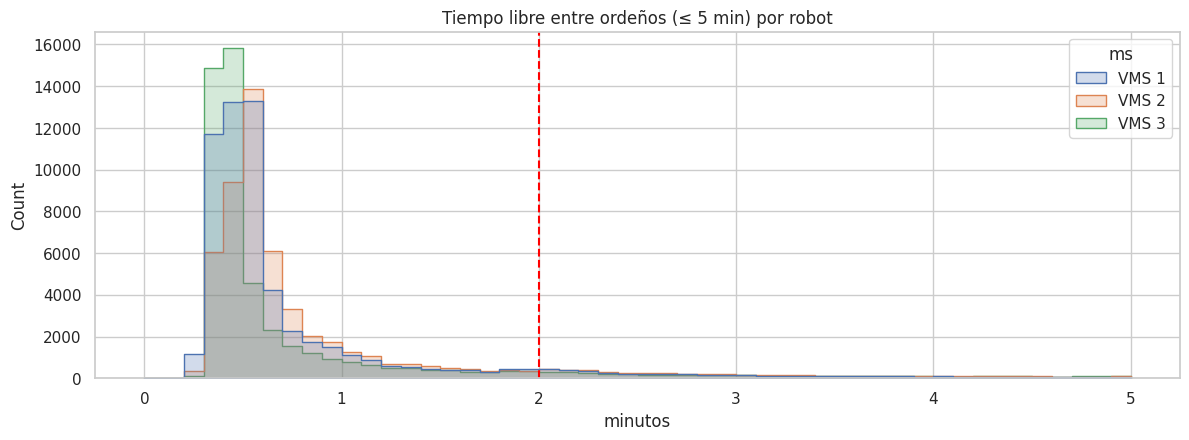

Moda del tiempo libre por robot (intervalos de 0.1 min):


,t
ms,
VMS 1,0.5
VMS 2,0.5
VMS 3,0.4


In [264]:
plt.figure(figsize=(14, 4.5))
sns.histplot(data=s[s["tiempo_libre_min"] <= 5], x="tiempo_libre_min", hue="ms", bins=np.arange(0, 5.1, 0.1), element="step")
plt.axvline(UMBRAL_COLA_MIN, color="red", ls="--", label=f"umbral {UMBRAL_COLA_MIN} min")
plt.title("Tiempo libre entre ordeños (≤ 5 min) por robot"); plt.xlabel("minutos"); plt.show()

print("Moda del tiempo libre por robot (intervalos de 0.1 min):")
s.assign(t=s["tiempo_libre_min"].round(1)).groupby("ms")["t"].agg(lambda x: x.mode().iloc[0])

## 18. Patrones temporales

Revisamos tres patrones:
- **Evolucion mensual** del porcentaje de ordeños con posible cola y de los ordeños por vaca al dia. Se usan porcentajes y promedios en lugar de conteos para que no se mezcle con el aumento de vacas en el historial.
- **Efecto de la alimentacion**, ya que el alimento se sirve aproximadamente a las 7:30 y 14:30 h.
- **Entre semana vs fin de semana.**

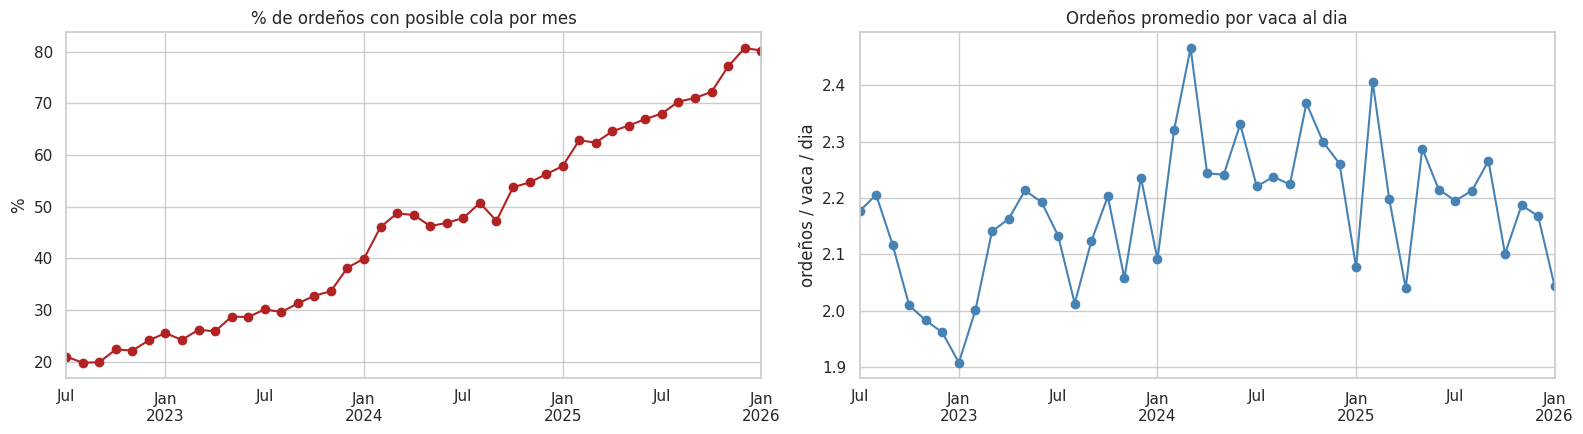

In [265]:
mensual = s.groupby("mes").agg(pct_cola=("posible_cola", "mean"), vacas=("id_vaca", "nunique"), ordeños=("id_vaca", "size"))
mensual["pct_cola"] *= 100
dias_mes = s.groupby("mes")["fecha"].nunique()
mensual["ordeños_por_vaca_dia"] = mensual["ordeños"] / mensual["vacas"] / dias_mes

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
mensual["pct_cola"].plot(ax=axes[0], marker="o", color="firebrick")
axes[0].set(title="% de ordeños con posible cola por mes", xlabel="", ylabel="%")
mensual["ordeños_por_vaca_dia"].plot(ax=axes[1], marker="o", color="steelblue")
axes[1].set(title="Ordeños promedio por vaca al dia", xlabel="", ylabel="ordeños / vaca / dia")
plt.tight_layout(); plt.show()

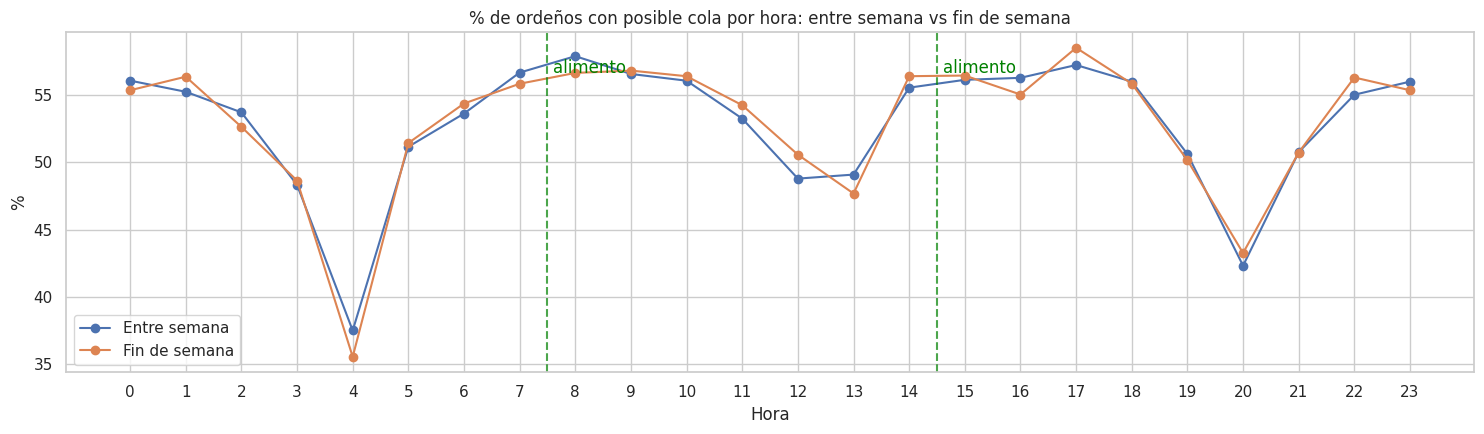

Alimento 7:30 h -> 2 h antes: 54.1 % | 2 h despues: 57.0 %
Alimento 14:30 h -> 2 h antes: 49.7 % | 2 h despues: 56.1 %


In [266]:
HORAS_ALIMENTO = [7.5, 14.5]   # 7:30 y 14:30

s["fin_de_semana"] = s["dia_semana"] >= 5
por_hora = s.groupby(["hora", "fin_de_semana"])["posible_cola"].mean().mul(100).unstack()
por_hora.columns = ["Entre semana", "Fin de semana"]

ax = por_hora.plot(figsize=(15, 4.5), marker="o")
for h in HORAS_ALIMENTO:
    ax.axvline(h, color="green", ls="--", alpha=0.7)
ax.text(HORAS_ALIMENTO[0] + 0.1, ax.get_ylim()[1] * 0.95, "alimento", color="green")
ax.text(HORAS_ALIMENTO[1] + 0.1, ax.get_ylim()[1] * 0.95, "alimento", color="green")
ax.set(title="% de ordeños con posible cola por hora: entre semana vs fin de semana", xlabel="Hora", ylabel="%")
ax.set_xticks(range(24)); plt.tight_layout(); plt.show()

# Comparacion antes y despues de cada horario de alimentacion (2 h antes vs 2 h despues)
for h in HORAS_ALIMENTO:
    hd = s["hora_inicio"].dt.hour + s["hora_inicio"].dt.minute / 60
    antes = s.loc[hd.between(h - 2, h, inclusive="left"), "posible_cola"].mean() * 100
    despues = s.loc[hd.between(h, h + 2, inclusive="left"), "posible_cola"].mean() * 100
    print(f"Alimento {int(h)}:{int((h % 1) * 60):02d} h -> 2 h antes: {antes:.1f} % | 2 h despues: {despues:.1f} %")

## 19. Relaciones entre variables

Revisamos las relaciones que mas se conectan con la formacion de colas:
- Duracion del ordeño vs produccion.
- Numero de vacas activas en el dia vs ocupacion media del robot.
- Numero de ordeño del dia (1.º, 2.º, 3.º...) vs posible cola.
- Las vacas que entran con mas frecuencia en posible cola, **normalizado** por su numero total de ordeños (en la seccion 15 el conteo favorecia a las vacas que se ordeñan mas veces).

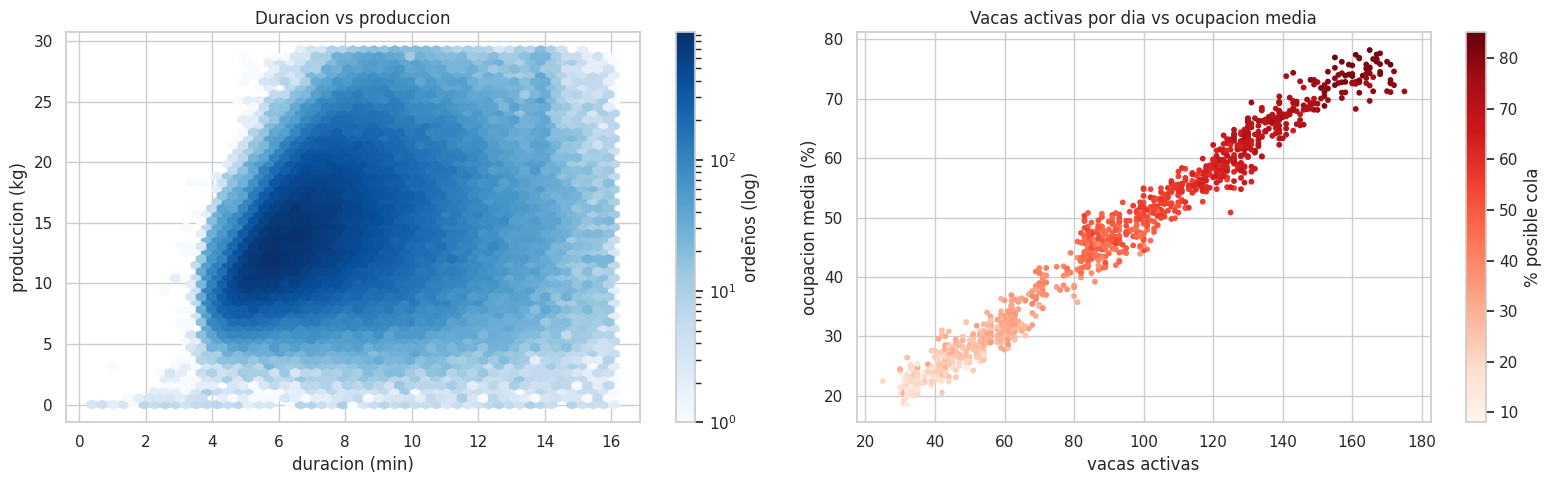

Correlacion (Pearson):
  duracion vs produccion: 0.25


,vacas_activas,ocupacion_media,pct_cola
vacas_activas,1.00,0.99,0.98
ocupacion_media,0.99,1.00,0.98
pct_cola,0.98,0.98,1.00


In [267]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
lim = df[["duracion_min", "produccion_kg"]].quantile(.99)
d = df[(df["duracion_min"] <= lim["duracion_min"]) & (df["produccion_kg"] <= lim["produccion_kg"])]
hb = axes[0].hexbin(d["duracion_min"], d["produccion_kg"], gridsize=50, cmap="Blues", mincnt=1, bins="log")
fig.colorbar(hb, ax=axes[0], label="ordeños (log)")
axes[0].set(title="Duracion vs produccion", xlabel="duracion (min)", ylabel="produccion (kg)")

# Vacas activas por dia vs ocupacion media del robot
diario = pd.DataFrame({
    "vacas_activas": df.groupby("fecha")["id_vaca"].nunique(),
    "ocupacion_media": ocup.groupby("fecha")["ocupacion_pct"].mean(),
    "pct_cola": s.groupby("fecha")["posible_cola"].mean() * 100,
}).dropna()
sc = axes[1].scatter(diario["vacas_activas"], diario["ocupacion_media"], c=diario["pct_cola"], cmap="Reds", s=10)
fig.colorbar(sc, ax=axes[1], label="% posible cola")
axes[1].set(title="Vacas activas por dia vs ocupacion media", xlabel="vacas activas", ylabel="ocupacion media (%)")
plt.tight_layout(); plt.show()

print("Correlacion (Pearson):")
print(f"  duracion vs produccion: {df['duracion_min'].corr(df['produccion_kg']):.2f}")
display(diario.corr().round(2))

,ordeños,pct_cola
numero_ordenio,,
1,115368,53.0
2,103307,54.2
3,50912,54.2
4,8852,55.2
5,503,58.3
6,19,26.3


Top 10 vacas con mayor proporcion de entradas en posible cola (≥ 100 ordeños):


,ordeños,veces_en_cola,proporcion
1519,178,157,0.882
1510,276,239,0.866
1538,149,128,0.859
1514,237,200,0.844
8797,166,140,0.843
1515,122,102,0.836
1522,116,97,0.836
8767,590,483,0.819
1526,127,104,0.819
8789,461,376,0.816


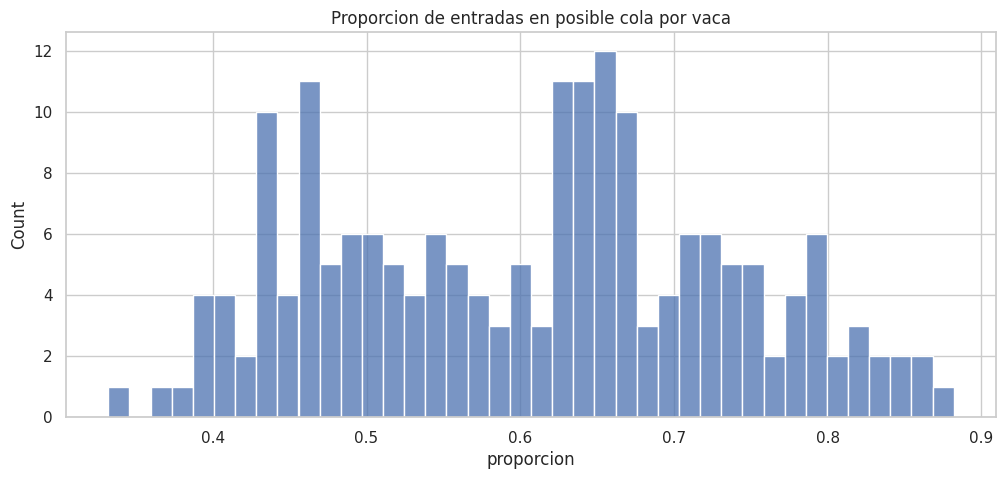

In [268]:
# Posible cola segun el numero de ordeño del dia
por_numero = s.groupby("numero_ordenio").agg(ordeños=("posible_cola", "size"), pct_cola=("posible_cola", "mean"))
por_numero["pct_cola"] = (por_numero["pct_cola"] * 100).round(1)
display(por_numero)

# Vacas que entran en posible cola, normalizado por su total de ordeños
MIN_ORDENIOS = 100   # se excluyen vacas con muy pocos registros
total_vaca = s.groupby("id_vaca").size()
siguiente = s.assign(siguiente_vaca=s.groupby("ms")["id_vaca"].shift(-1))
entra_en_cola = siguiente.loc[siguiente["posible_cola"]].groupby("siguiente_vaca").size()

tasa_vaca = pd.DataFrame({"ordeños": total_vaca, "veces_en_cola": entra_en_cola}).fillna(0)
tasa_vaca = tasa_vaca[tasa_vaca["ordeños"] >= MIN_ORDENIOS]
tasa_vaca["proporcion"] = (tasa_vaca["veces_en_cola"] / tasa_vaca["ordeños"]).round(3)

print(f"Top 10 vacas con mayor proporcion de entradas en posible cola (≥ {MIN_ORDENIOS} ordeños):")
display(tasa_vaca.sort_values("proporcion", ascending=False).head(10))

sns.histplot(tasa_vaca["proporcion"], bins=40)
plt.title("Proporcion de entradas en posible cola por vaca"); plt.xlabel("proporcion"); plt.show()

## 20. Comparacion de las relaciones entre 2024 y 2025

En la seccion 19 la correlacion entre vacas activas, ocupacion y posible cola salio cercana a 0.98, pero en todo el periodo el hato crece de 34 a 182 vacas, por lo que las tres variables suben con el tiempo y la correlacion puede venir solo de esa tendencia. Para revisarlo repetimos el calculo por separado para 2024 y 2025 (años completos) y los comparamos.

Ademas calculamos una version **sin tendencia**: a cada valor diario le restamos su media movil de 30 dias, de modo que solo se compara si en los dias con mas vacas de lo normal (para esa epoca) tambien hay mas ocupacion y mas cola.

Para cada ordeño marcamos `entro_en_cola`, que indica si la vaca entro al robot con 2 min o menos despues del ordeño anterior (es decir, probablemente estaba esperando).

In [269]:
AÑOS_COMPARAR = [2024, 2025]

# ¿La vaca entro al robot justo despues de otro ordeño? (el ordeño anterior en el mismo robot tuvo posible cola)
s = s.sort_values(["ms", "hora_inicio"])
s["entro_en_cola"] = s.groupby("ms")["posible_cola"].shift(1).fillna(False).astype(bool)

def datos_año(año):
    d_año = df[df["hora_inicio"].dt.year == año]
    s_año = s[s["hora_inicio"].dt.year == año]
    o_año = ocup[pd.to_datetime(ocup["fecha"]).dt.year == año]
    diario = pd.DataFrame({
        "vacas_activas": d_año.groupby("fecha")["id_vaca"].nunique(),
        "ocupacion_media": o_año.groupby("fecha")["ocupacion_pct"].mean(),
        "pct_cola": s_año.groupby("fecha")["posible_cola"].mean() * 100,
    }).dropna()
    diario.index = pd.to_datetime(diario.index)
    sin_tendencia = diario - diario.rolling(30, center=True, min_periods=15).mean()
    return d_año, s_año, diario, sin_tendencia

comparacion = {}
diarios = {}
for año in AÑOS_COMPARAR:
    d_año, s_año, diario, sin_tend = datos_año(año)
    diarios[año] = diario
    corr, corr_st = diario.corr(), sin_tend.corr()
    pct_numero = s_año.groupby("numero_ordenio")["posible_cola"].mean() * 100
    comparacion[año] = {
        "vacas activas (min - max por dia)": f"{diario['vacas_activas'].min():.0f} - {diario['vacas_activas'].max():.0f}",
        "ordeños": f"{len(d_año):,}",
        "% ordeños con posible cola": round(s_año["posible_cola"].mean() * 100, 1),
        "corr duracion vs produccion": round(d_año["duracion_min"].corr(d_año["produccion_kg"]), 2),
        "corr vacas activas vs ocupacion": round(corr.loc["vacas_activas", "ocupacion_media"], 2),
        "corr vacas activas vs % cola": round(corr.loc["vacas_activas", "pct_cola"], 2),
        "corr ocupacion vs % cola": round(corr.loc["ocupacion_media", "pct_cola"], 2),
        "corr vacas activas vs ocupacion (sin tendencia)": round(corr_st.loc["vacas_activas", "ocupacion_media"], 2),
        "corr vacas activas vs % cola (sin tendencia)": round(corr_st.loc["vacas_activas", "pct_cola"], 2),
        "corr ocupacion vs % cola (sin tendencia)": round(corr_st.loc["ocupacion_media", "pct_cola"], 2),
        "% cola 1.er ordeño del dia": round(pct_numero.get(1, np.nan), 1),
        "% cola 2.º ordeño del dia": round(pct_numero.get(2, np.nan), 1),
        "% cola 3.er ordeño del dia": round(pct_numero.get(3, np.nan), 1),
    }

comparacion = pd.DataFrame(comparacion)
comparacion

/tmp/ipykernel_1827/1073734793.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  s["entro_en_cola"] = s.groupby("ms")["posible_cola"].shift(1).fillna(False).astype(bool)


,2024,2025
vacas activas (min - max por dia),76 - 113,108 - 165
ordeños,"85,566","117,320"
% ordeños con posible cola,49.3,68.9
corr duracion vs produccion,0.26,0.23
corr vacas activas vs ocupacion,0.81,0.92
corr vacas activas vs % cola,0.67,0.91
corr ocupacion vs % cola,0.8,0.92
corr vacas activas vs ocupacion (sin tendencia),0.15,0.2
corr vacas activas vs % cola (sin tendencia),0.06,0.13
corr ocupacion vs % cola (sin tendencia),0.47,0.51


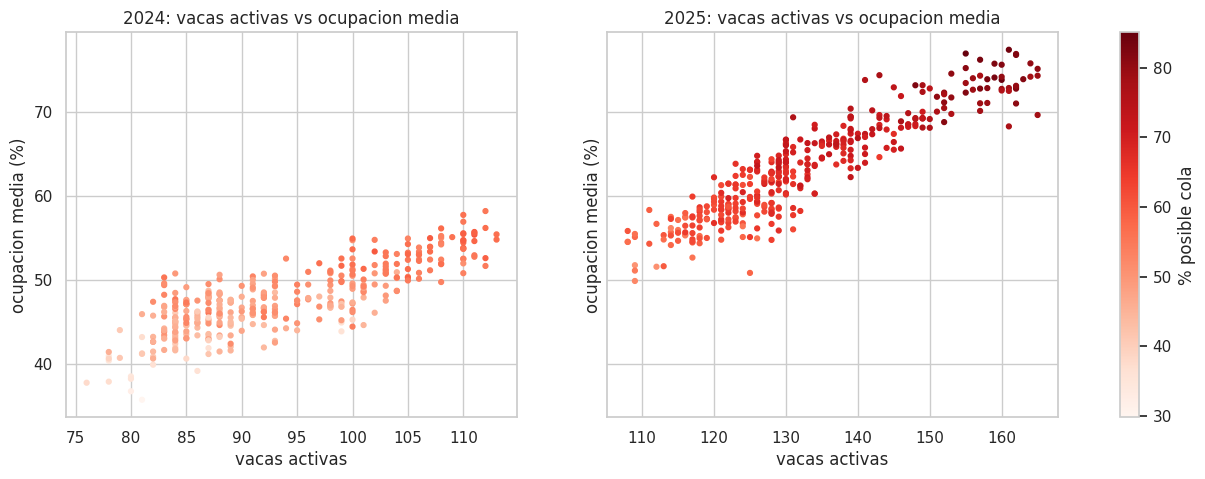

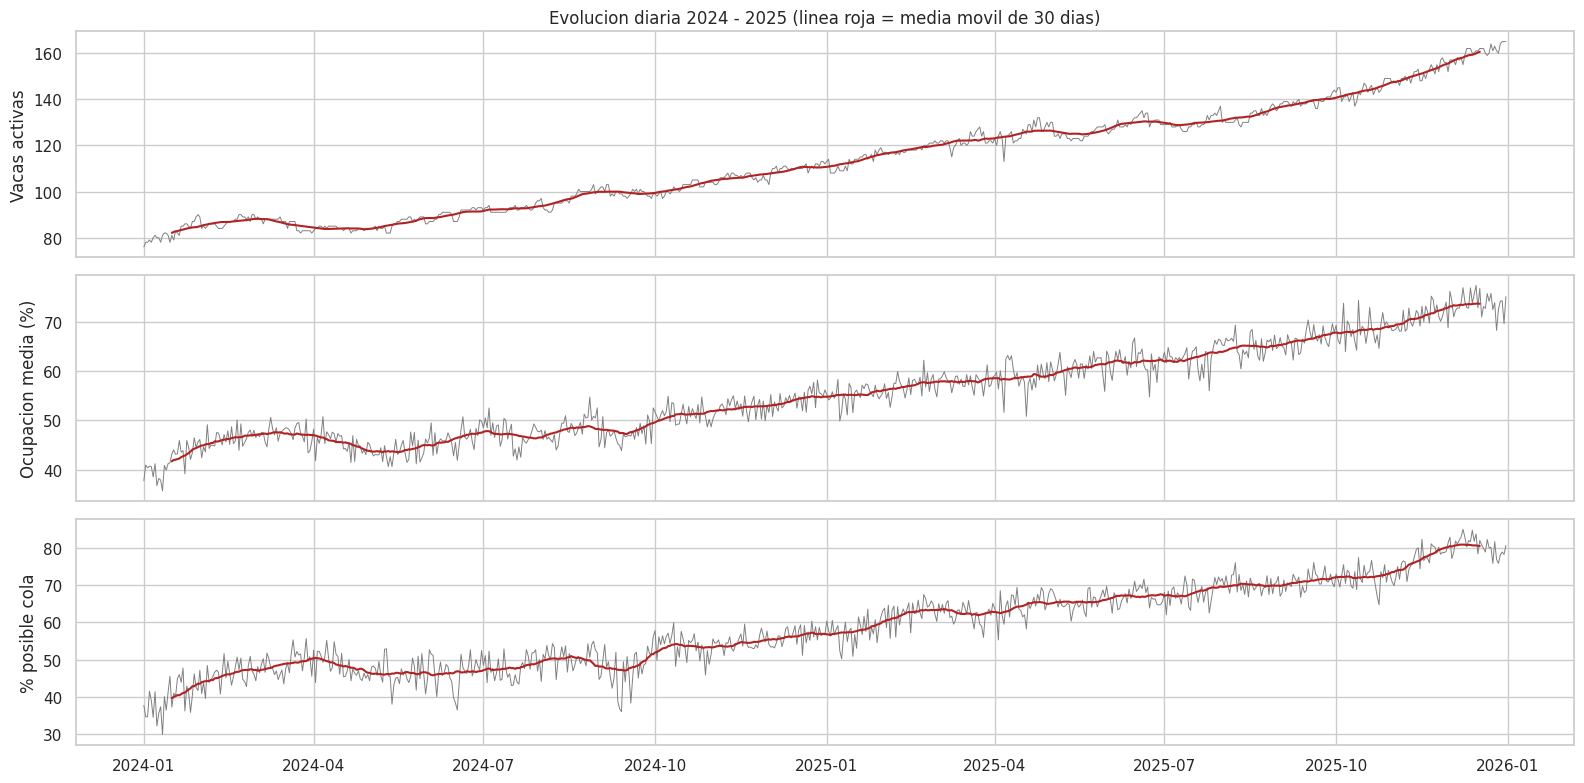

In [270]:
# Misma grafica de la seccion 19 para cada año, con la misma escala de color
vmin = min(d["pct_cola"].min() for d in diarios.values())
vmax = max(d["pct_cola"].max() for d in diarios.values())

fig, axes = plt.subplots(1, len(AÑOS_COMPARAR), figsize=(16, 5), sharey=True)
for ax, año in zip(axes, AÑOS_COMPARAR):
    d = diarios[año]
    sc = ax.scatter(d["vacas_activas"], d["ocupacion_media"], c=d["pct_cola"], cmap="Reds", s=12, vmin=vmin, vmax=vmax)
    ax.set(title=f"{año}: vacas activas vs ocupacion media", xlabel="vacas activas", ylabel="ocupacion media (%)")
fig.colorbar(sc, ax=axes, label="% posible cola")
plt.show()

# Evolucion diaria de las tres variables (para ver si suben juntas con el tiempo)
fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)
todo = pd.concat(diarios.values())
for ax, col, titulo in zip(axes, ["vacas_activas", "ocupacion_media", "pct_cola"],
                           ["Vacas activas", "Ocupacion media (%)", "% posible cola"]):
    ax.plot(todo.index, todo[col], lw=0.7, color="gray")
    ax.plot(todo.index, todo[col].rolling(30, center=True).mean(), color="firebrick")
    ax.set_ylabel(titulo)
axes[0].set_title("Evolucion diaria 2024 - 2025 (linea roja = media movil de 30 dias)")
plt.tight_layout(); plt.show()

In [271]:
# Top de vacas por año (proporcion de entradas en posible cola, normalizado)
MIN_ORDENIOS = 100

def tasa_por_vaca(s_año):
    t = s_año.groupby("id_vaca").agg(ordeños=("entro_en_cola", "size"), veces_en_cola=("entro_en_cola", "sum"))
    t = t[t["ordeños"] >= MIN_ORDENIOS]
    t["proporcion"] = (t["veces_en_cola"] / t["ordeños"]).round(3)
    return t.sort_values("proporcion", ascending=False)

tops = {}
for año in AÑOS_COMPARAR:
    t = tasa_por_vaca(s[s["hora_inicio"].dt.year == año])
    t["primer_registro"] = vida_vaca["primer_registro"].reindex(t.index).dt.strftime("%Y-%m-%d")
    tops[año] = t
    print(f"Top 10 vacas {año} (≥ {MIN_ORDENIOS} ordeños en el año):")
    display(t.head(10))

comunes = set(tops[AÑOS_COMPARAR[0]].head(20).index) & set(tops[AÑOS_COMPARAR[1]].head(20).index)
print(f"Vacas que aparecen en el top 20 de ambos años: {len(comunes)} -> {sorted(comunes)}")

Top 10 vacas 2024 (≥ 100 ordeños en el año):


,ordeños,veces_en_cola,proporcion,primer_registro
id_vaca,,,,
2150,503,316,0.628,2024-01-21
1236,331,207,0.625,2024-08-28
8702,370,227,0.614,2024-08-28
1243,323,198,0.613,2024-08-30
1203,109,65,0.596,2024-11-21
1237,223,131,0.587,2024-08-13
2144,425,248,0.584,2024-01-14
1233,318,185,0.582,2024-07-24
2123,619,358,0.578,2023-11-11


Top 10 vacas 2025 (≥ 100 ordeños en el año):


,ordeños,veces_en_cola,proporcion,primer_registro
id_vaca,,,,
1519,122,110,0.902,2025-09-29
1510,228,201,0.882,2025-08-27
8797,116,97,0.836,2025-09-16
1514,173,143,0.827,2025-10-12
8767,532,436,0.820,2025-03-31
8789,396,324,0.818,2025-07-22
8798,232,187,0.806,2025-09-01
1517,202,162,0.802,2025-10-07
8799,243,192,0.790,2025-08-25


Vacas que aparecen en el top 20 de ambos años: 0 -> []


## 21. ¿Las vacas nuevas tienen mas tendencia a estar en cola?

Las vacas del top de la seccion 19 tienen pocos ordeños y su primer registro es reciente, por lo que podrian ser vacas que acaban de entrar al hato (por ejemplo vacas de primer parto). En el Business Understanding se menciona que las vacas con menos experiencia suelen esperar mas porque las vacas dominantes se les adelantan.

Para revisarlo calculamos los **dias en el hato** de cada ordeño (dias desde el primer registro de la vaca) y comparamos el porcentaje de entradas en posible cola segun la antigüedad. Se excluyen las vacas cuyo primer registro esta en el primer mes de datos, porque no sabemos cuando llegaron realmente.

Para no confundir el efecto de ser nueva con el efecto del periodo (en 2025 hay mas colas en general), hacemos dos comparaciones:
1. **Dentro de un mismo mes:** vacas nuevas (≤ 90 dias) contra el resto de vacas de ese mismo mes.
2. **La misma vaca en el tiempo:** para cada vaca comparamos su proporcion de cola en sus primeros 90 dias contra la de despues.

In [272]:
DIAS_NUEVA = 90   # ajustable: una vaca se considera nueva durante sus primeros 90 dias

inicio_datos = df["hora_inicio"].min()
s["primer_registro"] = s["id_vaca"].map(vida_vaca["primer_registro"])
s["dias_en_hato"] = (s["hora_inicio"] - s["primer_registro"]).dt.days
s["llegada_conocida"] = s["primer_registro"] > inicio_datos + pd.Timedelta(days=30)

a = s[s["llegada_conocida"]].copy()
a["antiguedad"] = pd.cut(a["dias_en_hato"], bins=[-1, 30, 90, 180, 365, np.inf],
                         labels=["0-30 dias", "30-90 dias", "90-180 dias", "180-365 dias", "> 1 año"])
a["año"] = a["hora_inicio"].dt.year

print(f"Vacas con llegada conocida: {a['id_vaca'].nunique()}\n")
print("% de entradas en posible cola segun antigüedad y año:")
tabla_antig = a.pivot_table(index="antiguedad", columns="año", values="entro_en_cola", aggfunc="mean", observed=False) * 100
display(tabla_antig.round(1))
print("Número de ordeños en cada grupo:")
display(a.pivot_table(index="antiguedad", columns="año", values="entro_en_cola", aggfunc="size", observed=False))

Vacas con llegada conocida: 164

% de entradas en posible cola segun antigüedad y año:


año,2022,2023,2024,2025,2026
antiguedad,,,,,
0-30 dias,15.2,27.3,48.8,63.9,72.2
30-90 dias,24.6,34.7,52.0,71.0,84.9
90-180 dias,27.3,34.3,54.0,70.5,81.4
180-365 dias,NaN,32.5,49.6,69.4,80.3
> 1 año,NaN,31.9,50.1,69.4,81.1


Número de ordeños en cada grupo:


año,2022,2023,2024,2025,2026
antiguedad,,,,,
0-30 dias,1017,1623,2746,2742,248
30-90 dias,1670,3805,7049,6472,634
90-180 dias,521,6637,9363,10977,665
180-365 dias,0,8476,12939,17313,1190
> 1 año,0,2563,25292,54493,5529


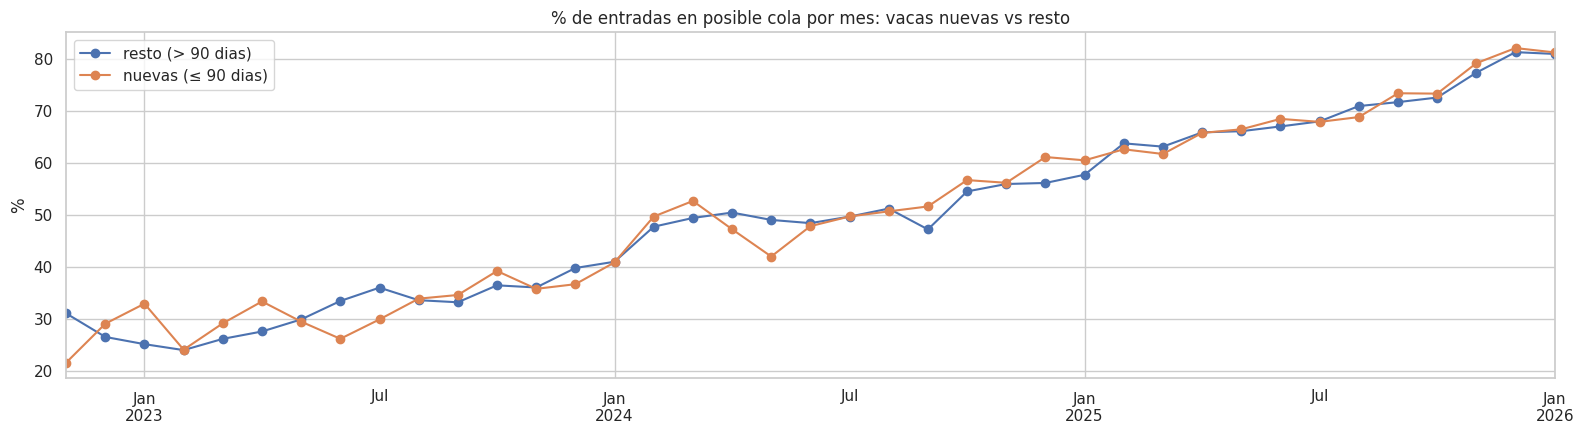

Meses comparados: 39
Meses en que las vacas nuevas tienen mayor % de cola: 23 (59%)
Diferencia promedio (nuevas - resto): +0.2 puntos porcentuales


In [273]:
# 1. Dentro del mismo mes: vacas nuevas vs resto
a["es_nueva"] = a["dias_en_hato"] <= DIAS_NUEVA
mensual_nueva = a.pivot_table(index="mes", columns="es_nueva", values="entro_en_cola", aggfunc="mean") * 100
mensual_nueva.columns = [f"resto (> {DIAS_NUEVA} dias)" if not c else f"nuevas (≤ {DIAS_NUEVA} dias)" for c in mensual_nueva.columns]
mensual_nueva = mensual_nueva.dropna()

ax = mensual_nueva.plot(figsize=(16, 4.5), marker="o")
ax.set(title="% de entradas en posible cola por mes: vacas nuevas vs resto", xlabel="", ylabel="%")
plt.tight_layout(); plt.show()

dif = mensual_nueva.iloc[:, 1] - mensual_nueva.iloc[:, 0]
print(f"Meses comparados: {len(dif)}")
print(f"Meses en que las vacas nuevas tienen mayor % de cola: {(dif > 0).sum()} ({(dif > 0).mean():.0%})")
print(f"Diferencia promedio (nuevas - resto): {dif.mean():+.1f} puntos porcentuales")

Vacas con ≥ 30 ordeños en ambas etapas: 142
Vacas con mas % de cola en sus primeros 90 dias: 5 (4%)
Diferencia promedio: -16.0 puntos porcentuales



,primeros_dias,despues,diferencia
count,142.0,142.0,142.0
mean,50.2,66.2,-16.0
std,17.9,10.7,9.9
min,14.1,41.9,-41.7
25%,36.1,58.3,-23.5
50%,52.1,66.8,-15.0
75%,64.9,73.4,-7.6
max,89.7,88.3,4.5


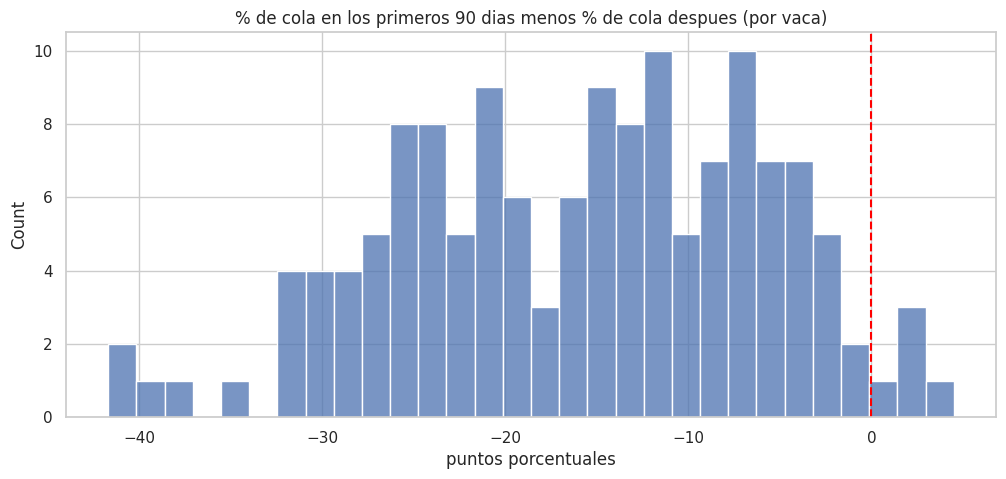

In [274]:
# 2. La misma vaca: primeros 90 dias vs despues
por_etapa = (a.assign(etapa=np.where(a["es_nueva"], "primeros_dias", "despues"))
               .groupby(["id_vaca", "etapa"])["entro_en_cola"].agg(["mean", "size"])
               .unstack("etapa"))
por_etapa = por_etapa[(por_etapa[("size", "primeros_dias")] >= 30) & (por_etapa[("size", "despues")] >= 30)]
pareado = pd.DataFrame({
    "primeros_dias": por_etapa[("mean", "primeros_dias")] * 100,
    "despues": por_etapa[("mean", "despues")] * 100,
})
pareado["diferencia"] = pareado["primeros_dias"] - pareado["despues"]

print(f"Vacas con ≥ 30 ordeños en ambas etapas: {len(pareado)}")
print(f"Vacas con mas % de cola en sus primeros {DIAS_NUEVA} dias: {(pareado['diferencia'] > 0).sum()} "
      f"({(pareado['diferencia'] > 0).mean():.0%})")
print(f"Diferencia promedio: {pareado['diferencia'].mean():+.1f} puntos porcentuales\n")
display(pareado.describe().round(1))

sns.histplot(pareado["diferencia"], bins=30)
plt.axvline(0, color="red", ls="--")
plt.title(f"% de cola en los primeros {DIAS_NUEVA} dias menos % de cola despues (por vaca)")
plt.xlabel("puntos porcentuales"); plt.show()

## 22. Intervalo entre ordeños de cada vaca y posibles ordeños forzados

En el VMS la vaca decide cuando ir al robot, pero si pasa demasiado tiempo sin ordeñarse el personal la lleva. Tomamos como referencia que si el intervalo entre dos ordeños de la misma vaca es **mayor a 4:30 h** probablemente fue llevada a la fuerza (umbral ajustable en `UMBRAL_FORZADO_H`).

El intervalo se calcula con las fechas de ordeños consecutivos de la misma vaca, y se excluyen los huecos mayores a 24 h (secado, corral de atencion, etc., ya analizados en la seccion 16.4). Revisamos:
- Cuantos ordeños pasan el umbral y como cambia el resultado con otros umbrales.
- En que horas ocurren (si se concentran en horas fijas, coincide con rondas del personal).
- La tendencia del intervalo por mes y por vaca (si cada vaca se ordeña mas o menos seguido con el tiempo).
- Si los ordeños forzados se relacionan con la posible cola.

Intervalos analizados: 275,917
Intervalos > 10 h: 109,797 (39.8%)



,count,mean,std,min,5%,10%,25%,50%,75%,90%,95%,max
intervalo (h),275917.0,9.76,3.42,0.01,5.21,5.99,7.4,9.17,11.56,14.32,16.24,24.0


% de intervalos mayores a cada umbral:


umbral (h),4.5,6.0,8.0,10.0,12.0,14.0,16.0
% ordeños,97.8,89.9,66.6,39.8,21.7,11.2,5.5


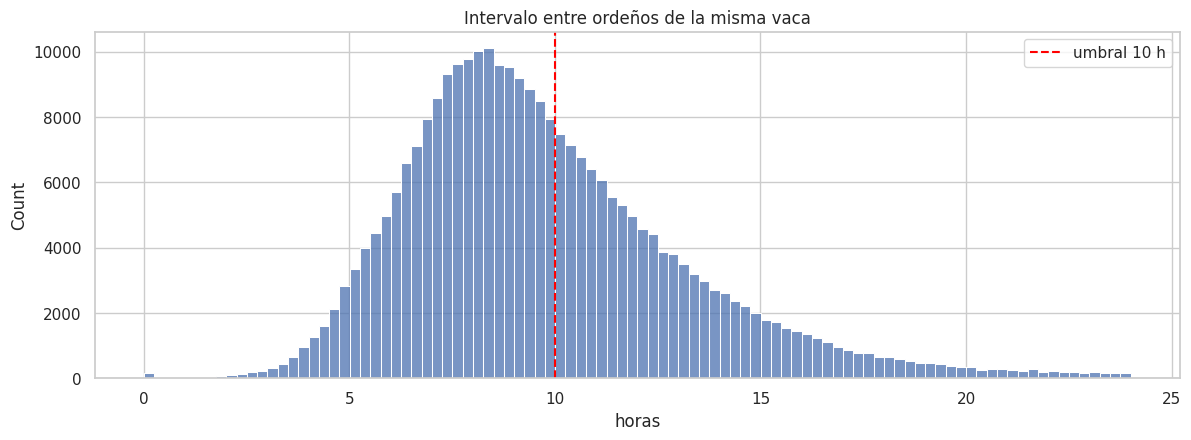

In [275]:
UMBRAL_FORZADO_H = 10   # ajustable: intervalo mayor a esto se considera posible ordeño forzado

iv = df.dropna(subset=["ms"]).sort_values(["id_vaca", "hora_inicio"]).copy()
iv["intervalo_real_h"] = iv.groupby("id_vaca")["hora_inicio"].diff().dt.total_seconds() / 3600
iv = iv[iv["intervalo_real_h"].between(0, 24)]
iv["posible_forzado"] = iv["intervalo_real_h"] > UMBRAL_FORZADO_H

print(f"Intervalos analizados: {len(iv):,}")
print(f"Intervalos > {UMBRAL_FORZADO_H} h: {iv['posible_forzado'].sum():,} ({iv['posible_forzado'].mean():.1%})\n")
display(iv["intervalo_real_h"].describe(percentiles=[.05, .1, .25, .5, .75, .9, .95]).round(2).to_frame("intervalo (h)").T)

# Sensibilidad: % de ordeños que pasan distintos umbrales
umbrales = [4.5, 6, 8, 10, 12, 14, 16]
print("% de intervalos mayores a cada umbral:")
display(pd.DataFrame({"umbral (h)": umbrales,
                      "% ordeños": [round((iv["intervalo_real_h"] > u).mean() * 100, 1) for u in umbrales]}).set_index("umbral (h)").T)

plt.figure(figsize=(14, 4.5))
sns.histplot(iv["intervalo_real_h"], bins=96)
plt.axvline(UMBRAL_FORZADO_H, color="red", ls="--", label=f"umbral {UMBRAL_FORZADO_H} h")
plt.title("Intervalo entre ordeños de la misma vaca"); plt.xlabel("horas"); plt.legend(); plt.show()

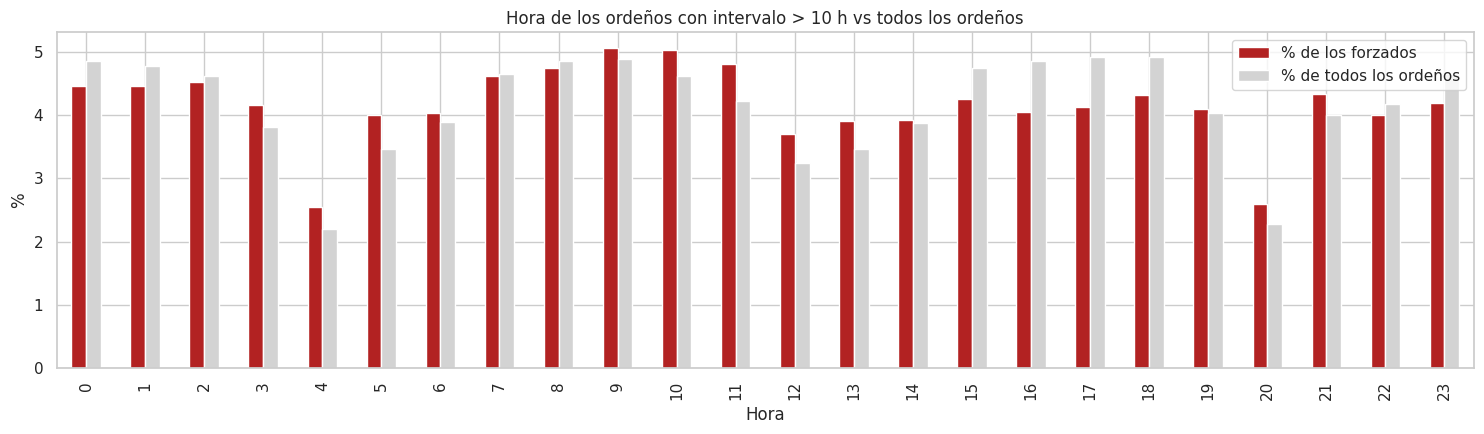

% de ordeños con intervalo > umbral en cada hora (top 5):


,posible_forzado
hora,
4,46.1
5,46.0
12,45.5
11,45.4
20,45.3


In [276]:
# ¿A que hora ocurren los posibles ordeños forzados? (comparado con todos los ordeños)
por_hora_forz = pd.DataFrame({
    "% de los forzados": iv.loc[iv["posible_forzado"], "hora"].value_counts(normalize=True).sort_index() * 100,
    "% de todos los ordeños": iv["hora"].value_counts(normalize=True).sort_index() * 100,
}).reindex(range(24), fill_value=0)

ax = por_hora_forz.plot.bar(figsize=(15, 4.5), color=["firebrick", "lightgray"])
ax.set(title=f"Hora de los ordeños con intervalo > {UMBRAL_FORZADO_H} h vs todos los ordeños", xlabel="Hora", ylabel="%")
plt.tight_layout(); plt.show()

print("% de ordeños con intervalo > umbral en cada hora (top 5):")
(iv.groupby("hora")["posible_forzado"].mean() * 100).sort_values(ascending=False).head(5).round(1)

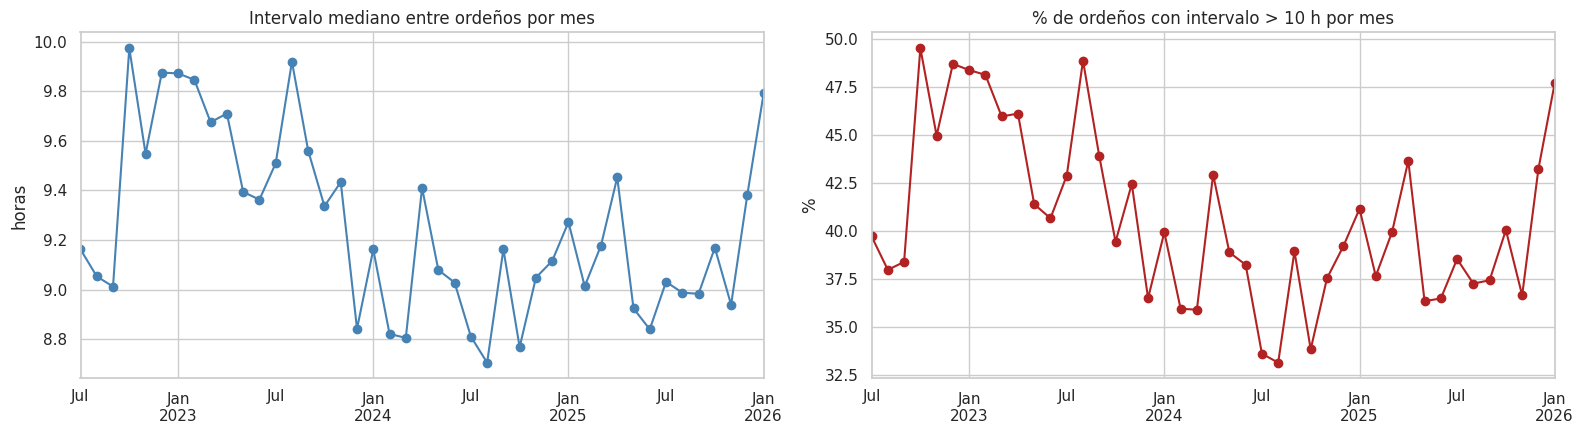

In [277]:
# Tendencia mensual del intervalo y del % de posibles forzados
mensual_iv = iv.groupby("mes").agg(intervalo_mediano_h=("intervalo_real_h", "median"),
                                   pct_forzado=("posible_forzado", "mean"))
mensual_iv["pct_forzado"] *= 100

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
mensual_iv["intervalo_mediano_h"].plot(ax=axes[0], marker="o", color="steelblue")
axes[0].set(title="Intervalo mediano entre ordeños por mes", xlabel="", ylabel="horas")
mensual_iv["pct_forzado"].plot(ax=axes[1], marker="o", color="firebrick")
axes[1].set(title=f"% de ordeños con intervalo > {UMBRAL_FORZADO_H} h por mes", xlabel="", ylabel="%")
plt.tight_layout(); plt.show()

Vacas con ≥ 6 meses de datos: 174
  intervalo aumenta con el tiempo (pendiente > 0): 24
  intervalo disminuye con el tiempo (pendiente < 0): 150

Vacas con mayor % de posibles ordeños forzados:


,ordeños,intervalo_mediano_h,% forzados,pendiente_h_por_mes
id_vaca,,,,
8794,253,14.55,85.8,0.477
1525,115,15.40,84.3,NaN
1515,116,13.62,81.0,NaN
1500,122,14.09,80.3,NaN
8741,460,12.64,80.2,-0.216
1519,171,13.17,80.1,NaN
8797,155,13.34,80.0,NaN
1524,152,13.44,78.3,NaN
1526,123,12.33,77.2,NaN


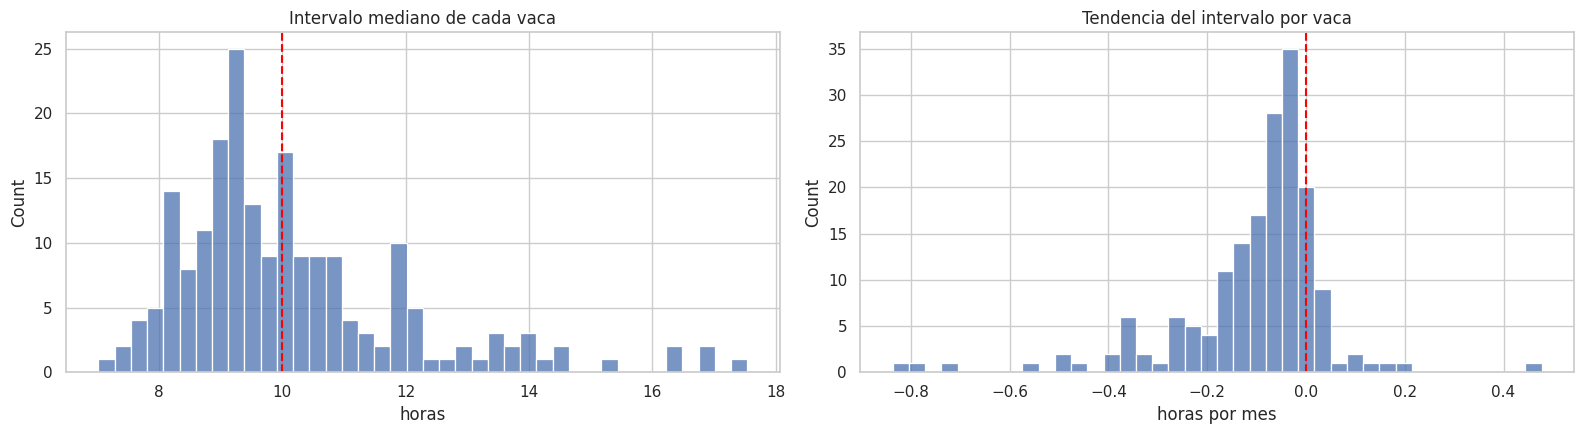

In [278]:
# Tendencia por vaca: pendiente del intervalo mediano mensual (horas por mes)
def pendiente(serie):
    serie = serie.dropna()
    if len(serie) < 6:   # al menos 6 meses de datos
        return np.nan
    return np.polyfit(np.arange(len(serie)), serie.values, 1)[0]

iv_vaca_mes = iv.groupby(["id_vaca", "mes"])["intervalo_real_h"].median()
tendencia_vaca = pd.DataFrame({
    "ordeños": iv.groupby("id_vaca").size(),
    "intervalo_mediano_h": iv.groupby("id_vaca")["intervalo_real_h"].median().round(2),
    "% forzados": (iv.groupby("id_vaca")["posible_forzado"].mean() * 100).round(1),
    "pendiente_h_por_mes": iv_vaca_mes.groupby("id_vaca").apply(pendiente).round(3),
})

con_tend = tendencia_vaca.dropna(subset=["pendiente_h_por_mes"])
print(f"Vacas con ≥ 6 meses de datos: {len(con_tend)}")
print(f"  intervalo aumenta con el tiempo (pendiente > 0): {(con_tend['pendiente_h_por_mes'] > 0).sum()}")
print(f"  intervalo disminuye con el tiempo (pendiente < 0): {(con_tend['pendiente_h_por_mes'] < 0).sum()}\n")

print("Vacas con mayor % de posibles ordeños forzados:")
display(tendencia_vaca[tendencia_vaca["ordeños"] >= MIN_ORDENIOS].sort_values("% forzados", ascending=False).head(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
sns.histplot(tendencia_vaca["intervalo_mediano_h"], bins=40, ax=axes[0])
axes[0].axvline(UMBRAL_FORZADO_H, color="red", ls="--")
axes[0].set(title="Intervalo mediano de cada vaca", xlabel="horas")
sns.histplot(con_tend["pendiente_h_por_mes"], bins=40, ax=axes[1])
axes[1].axvline(0, color="red", ls="--")
axes[1].set(title="Tendencia del intervalo por vaca", xlabel="horas por mes")
plt.tight_layout(); plt.show()

In [279]:
# Relacion de los posibles forzados con la posible cola y con la antigüedad de la vaca
iv["entro_en_cola"] = s["entro_en_cola"].reindex(iv.index).astype(float)
iv["dias_en_hato"] = s["dias_en_hato"].reindex(iv.index)

print("% de entradas en posible cola segun si el ordeño fue posible forzado:")
display((iv.groupby("posible_forzado")["entro_en_cola"].mean() * 100).round(1).to_frame("% entro en cola"))

print("% de posibles forzados segun antigüedad de la vaca:")
antig_iv = pd.cut(iv["dias_en_hato"], bins=[-1, 30, 90, 180, 365, np.inf],
                  labels=["0-30 dias", "30-90 dias", "90-180 dias", "180-365 dias", "> 1 año"])
(iv.groupby(antig_iv, observed=False)["posible_forzado"].mean() * 100).round(1).to_frame("% forzados")

% de entradas en posible cola segun si el ordeño fue posible forzado:


,% entro en cola
posible_forzado,
False,53.5
True,54.2


% de posibles forzados segun antigüedad de la vaca:


,% forzados
dias_en_hato,
0-30 dias,55.5
30-90 dias,47.7
90-180 dias,47.4
180-365 dias,44.5
> 1 año,34.3


## 23. Comparativa por grupo de vacas y etapa de la lactancia

No hay una columna con la fecha de parto, por lo que reconstruimos el ciclo de lactancia de cada vaca a partir de los secados de la seccion 16.5:
- Una **lactancia empieza** en el primer ordeño despues de un secado (hueco ≥ `UMBRAL_SECADO_DIAS`), o en el primer registro de la vaca si llego despues del primer mes de datos (las vacas entran al VMS despues de parir).
- Si la vaca ya estaba desde el inicio de los datos, no sabemos cuando empezo esa primera lactancia, por lo que esos ordeños se excluyen del analisis por etapa.
- Los **dias en leche (DEL)** son los dias desde el inicio de la lactancia.

Con esto clasificamos cada ordeño en dos agrupaciones:
- **Etapa de la lactancia** (segun el Business Understanding): fresca (0-100 DEL), alta produccion (100-200 DEL), baja produccion (200-305 DEL) y extendida (> 305 DEL).
- **Grupo de la vaca:** primer parto probable (primera lactancia de una vaca que llego durante el periodo de datos) y multipara (segunda lactancia observada o mas).

Comparamos produccion, duracion, intervalo entre ordeños, % de posibles forzados y % de entradas en posible cola. Para quitar el efecto del periodo (en 2025 hay mas colas en general), la cola tambien se mide como **diferencia contra el promedio del mismo mes**.

In [280]:
lac = df.sort_values(["id_vaca", "hora_inicio"]).copy()
lac["dias_sin_ordeño"] = lac.groupby("id_vaca")["hora_inicio"].diff().dt.total_seconds() / 86400
es_primero = lac["dias_sin_ordeño"].isna()
llegada_conocida = lac["id_vaca"].map(vida_vaca["primer_registro"]) > inicio_datos + pd.Timedelta(days=30)

# Cada segmento empieza en el primer registro de la vaca o despues de un secado
nuevo_segmento = es_primero | (lac["dias_sin_ordeño"] >= UMBRAL_SECADO_DIAS)
lac["segmento"] = nuevo_segmento.groupby(lac["id_vaca"]).cumsum()
lac["inicio_conocido"] = (lac["segmento"] > 1) | llegada_conocida
lac["inicio_lactancia"] = lac.groupby(["id_vaca", "segmento"])["hora_inicio"].transform("min")
lac["dias_en_leche"] = np.where(lac["inicio_conocido"],
                                (lac["hora_inicio"] - lac["inicio_lactancia"]).dt.days, np.nan)

lac["etapa_lactancia"] = pd.cut(lac["dias_en_leche"], bins=[-1, 100, 200, 305, np.inf],
                                labels=["fresca (0-100)", "alta prod. (100-200)", "baja prod. (200-305)", "extendida (> 305)"])
lac["grupo_vaca"] = np.select(
    [(lac["segmento"] == 1) & llegada_conocida, lac["segmento"] > 1],
    ["primer parto (probable)", "multipara"], default="desconocido")

# Variables de las secciones anteriores (mismo indice que df)
lac["entro_en_cola"] = s["entro_en_cola"].reindex(lac.index).astype(float)
lac["intervalo_real_h"] = iv["intervalo_real_h"].reindex(lac.index)
lac["posible_forzado"] = iv["posible_forzado"].reindex(lac.index).astype(float)
lac["cola_vs_mes"] = (lac["entro_en_cola"] - lac.groupby("mes")["entro_en_cola"].transform("mean")) * 100

con_del = lac.dropna(subset=["dias_en_leche"])
print(f"Ordeños con dias en leche conocidos: {len(con_del):,} de {len(lac):,} ({len(con_del) / len(lac):.0%})")
print(f"Lactancias identificadas: {con_del.groupby(['id_vaca', 'segmento']).ngroups}")
display(pd.crosstab(con_del["etapa_lactancia"], con_del["grupo_vaca"], margins=True, margins_name="total"))

Ordeños con dias en leche conocidos: 263,404 de 278,968 (94%)
Lactancias identificadas: 415


grupo_vaca,multipara,primer parto (probable),total
etapa_lactancia,,,
fresca (0-100),64640,31253,95893
alta prod. (100-200),48913,30773,79686
baja prod. (200-305),36161,26161,62322
extendida (> 305),16325,9178,25503
total,166039,97365,263404


In [281]:
# Comparativa por grupo de vaca y etapa de la lactancia
comparativa_lac = (con_del[con_del["grupo_vaca"] != "desconocido"]
    .groupby(["grupo_vaca", "etapa_lactancia"], observed=True)
    .agg(vacas=("id_vaca", "nunique"),
         ordeños=("id_vaca", "size"),
         produccion_kg=("produccion_kg", "mean"),
         duracion_min=("duracion_min", "mean"),
         intervalo_mediano_h=("intervalo_real_h", "median"),
         pct_forzados=("posible_forzado", "mean"),
         pct_entro_en_cola=("entro_en_cola", "mean"),
         cola_vs_mes_pp=("cola_vs_mes", "mean")))
comparativa_lac[["pct_forzados", "pct_entro_en_cola"]] *= 100
comparativa_lac.round(2)

vacas  ordeños  produccion_kg  \
grupo_vaca              etapa_lactancia                                       
multipara               fresca (0-100)          133    64640          16.80   
                        alta prod. (100-200)    120    48913          16.45   
                        baja prod. (200-305)    106    36161          14.67   
                        extendida (> 305)        75    16325          12.23   
primer parto (probable) fresca (0-100)          164    31253          12.92   
                        alta prod. (100-200)    141    30773          13.71   
                        baja prod. (200-305)    126    26161          13.37   
                        extendida (> 305)        66     9178          12.47   

                                              duracion_min  \
grupo_vaca              etapa_lactancia                      
multipara               fresca (0-100)                8.37   
                        alta prod. (100-200)          7.98   
                        baja prod. (200-305)          7.56   
                        extendida (> 305)             7.03   
primer parto (probable) fresca (0-100)                9.17   
                        alta prod. (100-200)          8.54   
                        baja prod. (200-305)          7.94   
                        extendida (> 305)             7.56   

                                              intervalo_mediano_h  \
grupo_vaca              etapa_lactancia                             
multipara               fresca (0-100)                       8.17   
                        alta prod. (100-200)                 8.74   
                        baja prod. (200-305)                 9.49   
                        extendida (> 305)                    9.74   
primer parto (probable) fresca (0-100)                      10.18   
                        alta prod. (100-200)                 9.74   
                        baja prod. (200-305)                 9.69   
                        extendida (> 305)                    9.64   

                                              pct_forzados  pct_entro_en_cola  \
grupo_vaca              etapa_lactancia                                         
multipara               fresca (0-100)               26.55              55.57   
                        alta prod. (100-200)         33.58              58.15   
                        baja prod. (200-305)         43.46              56.25   
                        extendida (> 305)            46.66              53.44   
primer parto (probable) fresca (0-100)               51.90              51.84   
                        alta prod. (100-200)         46.69              56.04   
                        baja prod. (200-305)         46.14              55.81   
                        extendida (> 305)            45.19              55.28   

                                              cola_vs_mes_pp  
grupo_vaca              etapa_lactancia                       
multipara               fresca (0-100)                 -1.11  
                        alta prod. (100-200)            0.88  
                        baja prod. (200-305)           -1.02  
                        extendida (> 305)              -5.08  
primer parto (probable) fresca (0-100)                  1.66  
                        alta prod. (100-200)            3.41  
                        baja prod. (200-305)            1.31  
                        extendida (> 305)              -1.20

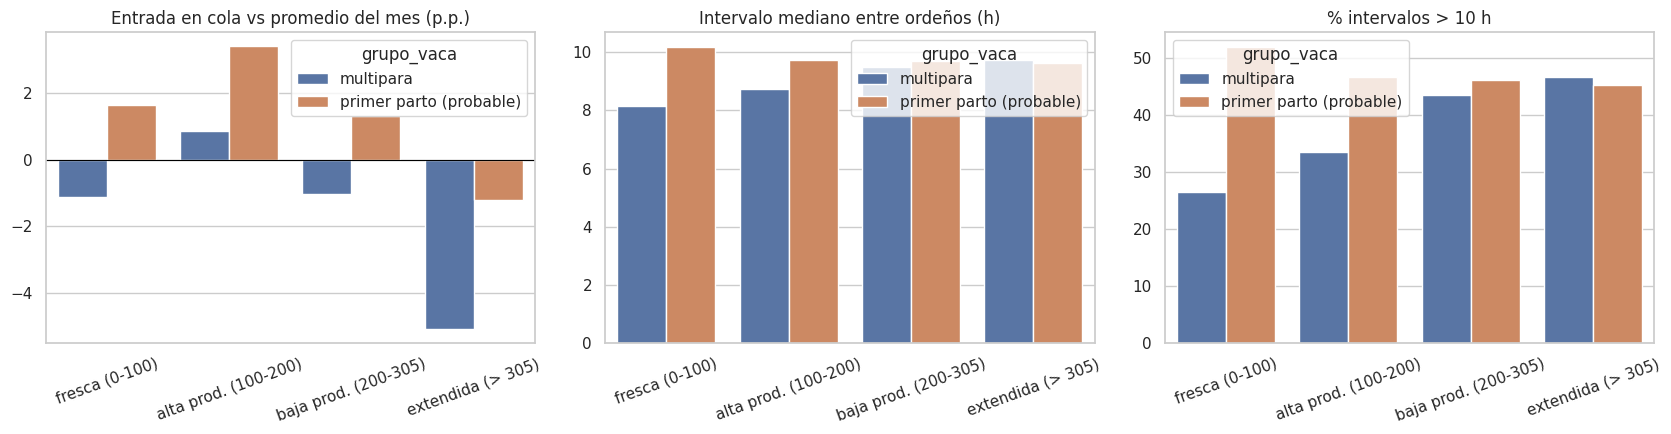

In [282]:
# Graficas de la comparativa
datos_graf = comparativa_lac.reset_index()
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, col, titulo in zip(axes, ["cola_vs_mes_pp", "intervalo_mediano_h", "pct_forzados"],
                           ["Entrada en cola vs promedio del mes (p.p.)", "Intervalo mediano entre ordeños (h)",
                            f"% intervalos > {UMBRAL_FORZADO_H} h"]):
    sns.barplot(data=datos_graf, x="etapa_lactancia", y=col, hue="grupo_vaca", ax=ax)
    ax.set(title=titulo, xlabel="", ylabel="")
    ax.tick_params(axis="x", rotation=20)
axes[0].axhline(0, color="black", lw=0.8)
plt.tight_layout(); plt.show()

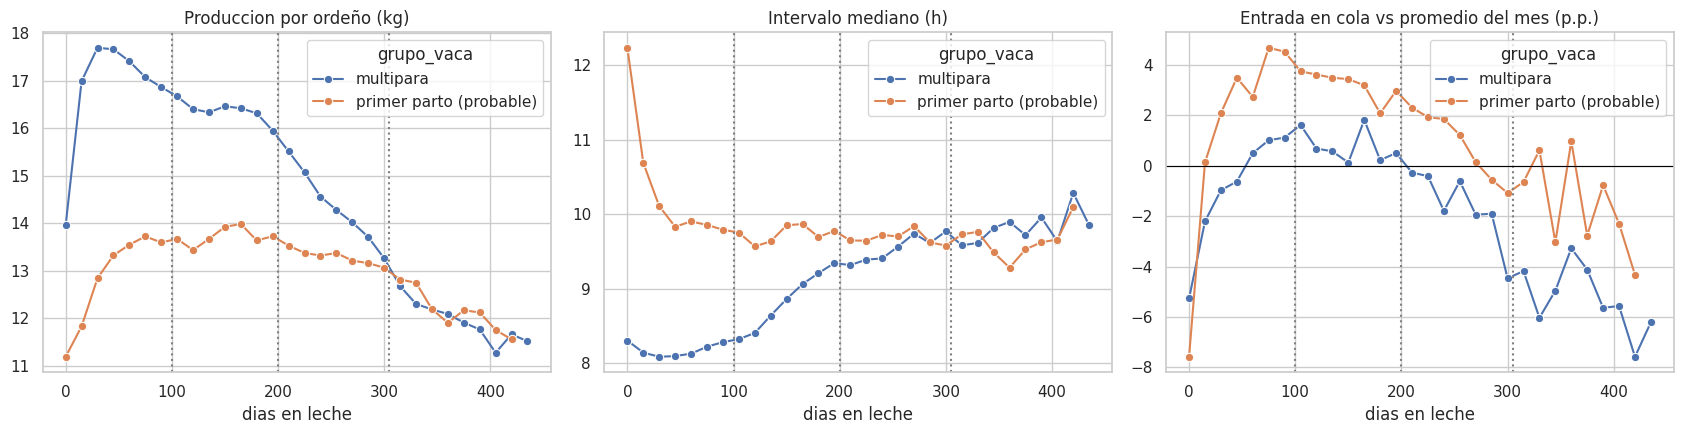

In [283]:
# Curva de lactancia: comportamiento segun los dias en leche (bloques de 15 dias)
curva = con_del[(con_del["grupo_vaca"] != "desconocido") & (con_del["dias_en_leche"] <= 450)].copy()
curva["bloque_del"] = (curva["dias_en_leche"] // 15) * 15
curva_g = curva.groupby(["grupo_vaca", "bloque_del"]).agg(
    produccion_kg=("produccion_kg", "mean"),
    intervalo_mediano_h=("intervalo_real_h", "median"),
    cola_vs_mes_pp=("cola_vs_mes", "mean"),
    ordeños=("id_vaca", "size")).reset_index()
curva_g = curva_g[curva_g["ordeños"] >= 200]   # se omiten bloques con pocos datos

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, col, titulo in zip(axes, ["produccion_kg", "intervalo_mediano_h", "cola_vs_mes_pp"],
                           ["Produccion por ordeño (kg)", "Intervalo mediano (h)", "Entrada en cola vs promedio del mes (p.p.)"]):
    sns.lineplot(data=curva_g, x="bloque_del", y=col, hue="grupo_vaca", marker="o", ax=ax)
    for limite in [100, 200, 305]:
        ax.axvline(limite, color="gray", ls=":")
    ax.set(title=titulo, xlabel="dias en leche", ylabel="")
axes[2].axhline(0, color="black", lw=0.8)
plt.tight_layout(); plt.show()

In [284]:
# Mismo analisis separado por año (para confirmar que no depende del periodo)
por_año_lac = (con_del[con_del["grupo_vaca"] != "desconocido"]
    .assign(año=lambda d: d["hora_inicio"].dt.year)
    .query("año in @AÑOS_COMPARAR")
    .pivot_table(index=["grupo_vaca", "etapa_lactancia"], columns="año",
                 values="cola_vs_mes", aggfunc="mean", observed=True))
print("Entrada en cola vs promedio del mes (puntos porcentuales) por año:")
por_año_lac.round(1)

Entrada en cola vs promedio del mes (puntos porcentuales) por año:


año                                           2024  2025
grupo_vaca              etapa_lactancia                 
multipara               fresca (0-100)        -1.6  -0.9
                        alta prod. (100-200)   1.6   0.8
                        baja prod. (200-305)  -1.9  -0.3
                        extendida (> 305)     -5.1  -4.1
primer parto (probable) fresca (0-100)         2.3   1.4
                        alta prod. (100-200)   4.1   2.1
                        baja prod. (200-305)   0.7   1.3
                        extendida (> 305)     -1.1  -2.8